# 01. 상가정보 불러와서 구조 확인하기

**목적**
부산 상가(상권)정보 CSV를 처음 열어보고, 어떤 데이터가 어떤 모양으로 들어있는지 파악하기 위해 작성했습니다. 아직 가공은 하지 않고 "생김새"만 확인하는 단계입니다.

**어떻게 했나**
pandas로 CSV를 불러오되, 서울시 상권분석 데이터(cp949)와 달리 이 데이터는 UTF-8 인코딩이라는 점을 [필독] 문서에서 미리 확인하고 그에 맞춰 읽었습니다. `shape`, `columns`, `head()`로 크기·컬럼·실제 값을 순서대로 확인했습니다.

**결과 / 알게 된 것**
159,689행, 39개 컬럼. 특히 `시군구명`이라는 컬럼이 이미 정리되어 있어서, 주소를 직접 파싱해서 구·군을 뽑아낼 필요가 없다는 걸 확인했습니다. 이후 모든 단계에서 이 컬럼을 그대로 활용합니다.

In [2]:
# ============================================================
# STEP 1. 부산 상가(상권)정보 데이터 불러와서 구조 확인하기
# ------------------------------------------------------------
# 이번 단계의 목표는 딱 하나예요:
#   "이 CSV 파일 안에 어떤 데이터가, 어떤 모양으로 들어있는지" 눈으로 확인하는 것.
#   아직 필터링이나 가공은 하지 않습니다.
# ============================================================

# pandas는 표(엑셀 시트 같은 것) 형태의 데이터를 다루는 파이썬 라이브러리예요.
# 앞으로 이 프로젝트 내내 계속 쓰게 될 도구라서 pd라는 별칭으로 불러옵니다.
import pandas as pd

# 불러올 파일 경로입니다.
# VS Code에서 "ABA_1st_proj_수정" 폴더를 열어놓은 상태를 기준으로 한 상대경로예요.
# (만약 다른 폴더를 워크스페이스로 열어두셨다면, 이 경로를 본인 환경에 맞게 수정해주세요.)
파일_경로 = r'C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv'

# CSV를 읽어옵니다.
# encoding="utf-8"을 꼭 지정해야 해요.
#   -> 이 데이터는 서울시 상권분석 데이터(cp949)와 다르게 UTF-8로 인코딩되어 있어서,
#      인코딩을 안 맞추면 한글이 깨지거나 아예 에러가 납니다. ([필독]파일열람방법.txt 참고)
df = pd.read_csv(r'C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv', encoding="utf-8")

# ------------------------------------------------------------
# 여기서부터는 "이 데이터가 어떻게 생겼는지" 확인하는 코드입니다.
# 하나씩 실행 결과를 보면서 데이터를 파악해보세요.
# ------------------------------------------------------------

# 1) 행(row)이 몇 개, 열(column)이 몇 개인지 확인
#    -> (행 개수, 열 개수) 형태의 튜플이 출력돼요.
print("데이터 크기 (행, 열):", df.shape)

# 2) 컬럼(열) 이름이 전부 뭐가 있는지 확인
#    -> 어떤 정보들이 들어있는지 한눈에 보는 목록이에요.
print("\n컬럼 목록:")
print(df.columns.tolist())

# 3) 실제 값이 어떻게 생겼는지 위에서 5줄만 미리보기
#    -> head()는 "맨 앞 몇 줄만 보여줘"라는 뜻이에요. 기본값이 5줄입니다.
print("\n상위 5행 미리보기:")
print(df.head())

데이터 크기 (행, 열): (159689, 39)

컬럼 목록:
['상가업소번호', '상호명', '지점명', '상권업종대분류코드', '상권업종대분류명', '상권업종중분류코드', '상권업종중분류명', '상권업종소분류코드', '상권업종소분류명', '표준산업분류코드', '표준산업분류명', '시도코드', '시도명', '시군구코드', '시군구명', '행정동코드', '행정동명', '법정동코드', '법정동명', '지번코드', '대지구분코드', '대지구분명', '지번본번지', '지번부번지', '지번주소', '도로명코드', '도로명', '건물본번지', '건물부번지', '건물관리번호', '건물명', '도로명주소', '구우편번호', '신우편번호', '동정보', '층정보', '호정보', '경도', '위도']

상위 5행 미리보기:
                 상가업소번호               상호명  지점명 상권업종대분류코드 상권업종대분류명 상권업종중분류코드  \
0  MA0106202201A0010117       SK에너지신도시주유소  NaN        G2       소매      G214   
1  MA0106202201A0824645  씨앤코컴퍼니블루포트영산대학교점  NaN        I2       음식      I201   
2  MA0106202201A0801375          아트몰링토니버거  NaN        I2       음식      I210   
3  MA0106202201A1870780           본원코렘어학원  NaN        P1       교육      P105   
4  MA0106202201A0522218        원더플레이스피에스타  서면점        G2       소매      G209   

      상권업종중분류명 상권업종소분류코드   상권업종소분류명 표준산업분류코드  ...                     건물관리번호  \
0        연료 소매    G21401        주유소   G4771

# 02. "카페" 업종명 확인하기

**목적**
업종 분류에서 "카페"만 필터링하기 전에, 이름이 비슷해서 헷갈릴 수 있는 업종이 있는지 미리 확인하기 위해 작성했습니다. 무작정 필터링하면 잘못된 업종이 섞여 들어갈 위험이 있습니다.

**어떻게 했나**
`상권업종소분류명`에서 "카페"라는 글자가 들어간 값들을 `str.contains()`로 찾고, `unique()`와 `value_counts()`로 어떤 이름들이 있고 각각 몇 개씩인지 확인했습니다.

**결과 / 알게 된 것**
"카페"(7,335개)와 "독서실/스터디 카페"(630개), 이렇게 완전히 다른 두 업종이 존재한다는 걸 확인했습니다. 다음 단계부터는 `contains`가 아니라 `== "카페"`로 정확히 일치하는 값만 걸러야 한다는 기준을 세웠습니다.

In [3]:
# ============================================================
# STEP 2. "카페"라는 이름이 들어간 업종이 정확히 뭐가 있는지 확인하기
# ------------------------------------------------------------
# 목표: 상권업종소분류명 컬럼에서 "카페"라는 글자가 들어간 값들을
#       전부 나열해서, 진짜 카페와 헷갈릴 수 있는 항목이 있는지 눈으로 확인.
#       (예: "카페"랑 "독서실/스터디 카페"는 완전히 다른 업종인데,
#        이름에 둘 다 "카페"가 들어있어서 자칫 잘못 섞일 수 있음)
# ============================================================

import pandas as pd

파일_경로 = r'C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv'
df = pd.read_csv(파일_경로, encoding="utf-8")

# ------------------------------------------------------------
# str.contains("카페") : "상권업종소분류명" 값 중에서
#                        "카페"라는 글자를 포함하는 행만 True로 표시해줍니다.
# .unique()            : 그 조건에 걸린 값들 중 중복을 제거하고
#                        어떤 종류가 있는지만 보여줍니다.
# ------------------------------------------------------------
카페_관련_업종명 = df[df["상권업종소분류명"].str.contains("카페", na=False)]["상권업종소분류명"].unique()

print("'카페'라는 글자가 들어간 업종 소분류명 목록:")
print(카페_관련_업종명)

# ------------------------------------------------------------
# 참고로, 업종별로 각각 몇 개씩 있는지도 같이 확인해볼게요.
# value_counts()는 각 값이 몇 번 나오는지 세어줍니다.
# ------------------------------------------------------------
print("\n각 업종별 개수:")
print(df[df["상권업종소분류명"].str.contains("카페", na=False)]["상권업종소분류명"].value_counts())

'카페'라는 글자가 들어간 업종 소분류명 목록:
<ArrowStringArray>
['카페', '독서실/스터디 카페']
Length: 2, dtype: str

각 업종별 개수:
상권업종소분류명
카페            7335
독서실/스터디 카페     630
Name: count, dtype: int64


# 03. 진짜 카페만 구·군별로 개수 세기

**목적**
02번에서 확인한 함정을 피해서 "진짜 카페"만 골라내고, 부산 구·군마다 카페가 몇 개씩 있는지 처음으로 집계해보기 위해 작성했습니다.

**어떻게 했나**
`상권업종소분류명 == "카페"`로 정확히 일치하는 행만 남긴 뒤, `groupby("시군구명").size()`로 구·군별 개수를 세고 많은 순으로 정렬했습니다.

**결과 / 알게 된 것**
부산진구(951개), 해운대구(784개) 순으로 카페가 많다는 걸 확인했습니다. 다만 이건 "그냥 개수"라서, 구가 크면 당연히 더 많아 보이는 착시가 있을 수 있다는 한계를 인지한 채 다음 단계로 넘어갔습니다.

In [4]:
# ============================================================
# STEP 3. "진짜 카페"만 골라서 구·군별로 몇 개씩 있는지 세어보기
# ------------------------------------------------------------
# 목표: 상권업종소분류명이 정확히 "카페"인 행만 남기고,
#       시군구명 기준으로 그룹을 지어서 각 구·군에 카페가 몇 개인지 확인.
# ============================================================

import pandas as pd

파일_경로 = r'C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv'
df = pd.read_csv(r'C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv', encoding="utf-8")

# ------------------------------------------------------------
# 여기서는 str.contains("카페") 대신 == "카페"를 씁니다.
#   - contains는 "카페"라는 글자가 포함되기만 하면 다 걸려서
#     "독서실/스터디 카페"까지 같이 딸려옵니다.
#   - == "카페"는 값이 정확히 "카페"인 행만 골라내기 때문에
#     독서실/스터디 카페는 자동으로 제외됩니다.
# ------------------------------------------------------------
카페_df = df[df["상권업종소분류명"] == "카페"]

print("필터링 전 전체 행 수:", len(df))
print("카페만 필터링한 행 수:", len(카페_df))

# ------------------------------------------------------------
# groupby("시군구명") : 시군구명이 같은 행끼리 하나의 묶음으로 만들어줍니다.
# .size()             : 각 묶음(각 구·군)에 행이 몇 개 있는지 세어줍니다.
# .sort_values(ascending=False) : 개수가 많은 구·군 순서로 정렬합니다.
# ------------------------------------------------------------
구군별_카페개수 = 카페_df.groupby("시군구명").size().sort_values(ascending=False)

print("\n부산 구·군별 카페 개수 (많은 순):")
print(구군별_카페개수)

필터링 전 전체 행 수: 159689
카페만 필터링한 행 수: 7335

부산 구·군별 카페 개수 (많은 순):
시군구명
부산진구    951
해운대구    784
금정구     553
동래구     526
기장군     512
수영구     493
남구      449
사하구     444
연제구     420
강서구     418
사상구     394
북구      346
중구      329
서구      252
동구      241
영도구     223
dtype: int64


# 04. 부산 + 경남 합치기

**목적**
프로젝트 대상 지역이 부산·경남 둘 다이기 때문에, 부산 하나로 검증한 로직을 경남까지 확장하기 위해 작성했습니다. 처음부터 두 지역을 합쳐서 시작하지 않고, 부산으로 먼저 코드를 검증한 뒤 합치는 순서를 택했습니다 (문제가 생겼을 때 코드 문제인지 데이터 문제인지 구분하기 쉽게 하려는 목적).

**어떻게 했나**
부산·경남 CSV를 각각 불러온 뒤, 두 파일의 컬럼 구성이 완전히 동일한 것을 미리 확인하고 `pd.concat()`으로 이어붙였습니다. 03번과 동일한 카페 필터링·집계 로직을 합쳐진 데이터에 그대로 반복했습니다.

**결과 / 알게 된 것**
합친 행 수(332,576)가 부산+경남 행 수와 정확히 일치함을 확인했습니다. 구·군별 순위에 김해시·진주시 등 경남 지역이 추가되었고, 창원시가 성산구·의창구 등 5개 구로 세분화되어 나온다는 것도 이때 처음 확인했습니다.

In [5]:
# ============================================================
# STEP 4. 부산 + 경남 데이터를 하나로 합쳐서 같은 분석 반복하기
# ------------------------------------------------------------
# 목표: 두 지역 CSV를 각각 불러온 뒤 하나의 표로 이어 붙이고(concat),
#       "카페" 필터링 + 시군구별 개수 세기를 합쳐진 데이터로 다시 실행.
#       (부산 CSV, 경남 CSV 둘 다 컬럼 구성이 완전히 동일한 걸 미리 확인했어요.)
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 두 파일을 각각 불러옵니다.
# ------------------------------------------------------------
부산_df = pd.read_csv(
    r'C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv',
    encoding="utf-8",
)
경남_df = pd.read_csv(
    r'C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_경남_202606.csv',
    encoding="utf-8",
)

# ------------------------------------------------------------
# pd.concat([...]) : 여러 개의 표를 위아래로 이어 붙여서 하나로 만들어줍니다.
# ignore_index=True : 이어 붙이면서 행 번호(인덱스)를 0부터 새로 매깁니다.
#                      (안 하면 부산 0~159688, 경남도 0~172886 이렇게
#                       인덱스가 중복돼서 헷갈릴 수 있어요.)
# ------------------------------------------------------------
합친_df = pd.concat([부산_df, 경남_df], ignore_index=True)

print("부산 행 수:", len(부산_df))
print("경남 행 수:", len(경남_df))
print("합친 행 수:", len(합친_df), "(부산 + 경남과 일치해야 정상)")

# ------------------------------------------------------------
# 이제 3단계에서 했던 것과 완전히 같은 로직을 합친 데이터에 적용합니다.
# ------------------------------------------------------------
카페_df = 합친_df[합친_df["상권업종소분류명"] == "카페"]

print("\n합친 데이터 중 카페 행 수:", len(카페_df))

구군별_카페개수 = 카페_df.groupby("시군구명").size().sort_values(ascending=False)

print("\n부산+경남 구·군별 카페 개수 (많은 순):")
print(구군별_카페개수)

부산 행 수: 159689
경남 행 수: 172887
합친 행 수: 332576 (부산 + 경남과 일치해야 정상)

합친 데이터 중 카페 행 수: 15724

부산+경남 구·군별 카페 개수 (많은 순):
시군구명
김해시          1179
진주시           984
부산진구          951
양산시           860
해운대구          784
창원시 성산구       621
거제시           556
금정구           553
동래구           526
기장군           512
수영구           493
창원시 마산합포구     470
창원시 의창구       470
창원시 진해구       462
남구            449
사하구           444
연제구           420
강서구           418
사상구           394
밀양시           357
창원시 마산회원구     357
통영시           347
북구            346
중구            329
사천시           310
서구            252
동구            241
영도구           223
창녕군           216
남해군           183
하동군           158
거창군           157
산청군           139
함안군           138
고성군           137
합천군           108
함양군            97
의령군            83
dtype: int64


# 05. 카페 + 빵/도넛 구·군별 비교표

**목적**
"베이커리 물류 회사가 카페를 낸다"는 프로젝트 스토리에 맞춰, 카페뿐 아니라 빵/도넛(제과점) 업종도 같이 살펴보기 위해 작성했습니다. 두 업종 개수를 구·군별로 나란히 볼 수 있는 표를 만드는 게 목표였습니다.

**어떻게 했나**
`isin(["카페", "빵/도넛"])`으로 두 업종만 남긴 뒤, `groupby(["시군구명", "상권업종소분류명"])`으로 구·군과 업종 두 기준으로 동시에 묶고, `unstack()`으로 세로로 쌓인 업종명을 가로 컬럼으로 펼쳤습니다. 이후 재사용할 수 있도록 CSV로 저장했습니다.

**결과 / 알게 된 것**
구·군별 카페·빵/도넛 개수 비교표(`구군별_카페_빵집_비교표.csv`)를 완성했습니다. "빵/도넛"은 "카페"와 달리 헷갈리는 유사 업종이 없어서, 02번 같은 사전 확인 없이도 바로 정확히 필터링할 수 있었습니다.

In [6]:
# ============================================================
# STEP 5. 카페 개수 + 빵/도넛(제과점) 개수를 구·군별로 나란히 비교하기
# ------------------------------------------------------------
# 목표: "베이커리 물류 회사가 카페를 낸다"는 프로젝트 스토리에 맞춰서,
#       카페뿐 아니라 빵/도넛 업종도 같이 세어보고,
#       구·군별로 두 업종 개수를 한 표에 나란히 놓고 봅니다.
#       (미리 확인해보니 "빵/도넛"은 "카페"와 달리 헷갈리는 유사 이름이 없어서
#        바로 정확히 일치하는 값으로 필터링해도 안전해요.)
# ============================================================

import pandas as pd

부산_df = pd.read_csv(
    r'C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv',
    encoding="utf-8",
)
경남_df = pd.read_csv(
    r'C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_경남_202606.csv',
    encoding="utf-8",
)
합친_df = pd.concat([부산_df, 경남_df], ignore_index=True)

# ------------------------------------------------------------
# isin(["카페", "빵/도넛"]) : 값이 "카페" 이거나 "빵/도넛" 인 행만 골라냅니다.
#                            (== 을 여러 번 | 로 잇는 것보다 깔끔한 방법이에요)
# ------------------------------------------------------------
관심업종_df = 합친_df[합친_df["상권업종소분류명"].isin(["카페", "빵/도넛"])]

print("카페 + 빵/도넛 합친 행 수:", len(관심업종_df))

# ------------------------------------------------------------
# groupby(["시군구명", "상권업종소분류명"]) : 시군구명과 업종명, 두 기준으로
#                                            동시에 그룹을 지어줍니다.
#                                            (구·군 하나당 "카페" 묶음, "빵/도넛" 묶음이 따로 생김)
# .size()      : 각 묶음의 행 개수를 셉니다.
# .unstack()   : 세로로 길게 쌓여있던 업종명을 가로 컬럼으로 펼쳐서
#                "구·군 하나당 한 줄, 카페 개수·빵집 개수 두 컬럼"인 표로 바꿔줍니다.
# .fillna(0)   : 만약 어떤 구·군에 카페나 빵집이 하나도 없어서 빈 값(NaN)이 생기면 0으로 채웁니다.
# ------------------------------------------------------------
구군별_비교표 = (
    관심업종_df.groupby(["시군구명", "상권업종소분류명"])
    .size()
    .unstack()
    .fillna(0)
    .astype(int)  # 개수는 소수점이 필요 없으니 정수로 바꿔줍니다.
)

# 카페가 많은 순서로 정렬해서 보기 좋게 만듭니다.
구군별_비교표 = 구군별_비교표.sort_values("카페", ascending=False)

print("\n구·군별 카페 vs 빵/도넛 개수 비교:")
print(구군별_비교표)

# ------------------------------------------------------------
# 나중에 이 표를 계속 재사용할 수 있게 CSV로 저장해둡니다.
# to_csv에 encoding="utf-8-sig"를 쓰면 엑셀에서 열어도 한글이 안 깨져요.
# ------------------------------------------------------------
구군별_비교표.to_csv("구군별_카페_빵집_비교표.csv", encoding="utf-8-sig")
print("\n'구군별_카페_빵집_비교표.csv' 파일로 저장 완료!")

카페 + 빵/도넛 합친 행 수: 19744

구·군별 카페 vs 빵/도넛 개수 비교:
상권업종소분류명   빵/도넛    카페
시군구명                 
김해시         304  1179
진주시         273   984
부산진구        258   951
양산시         218   860
해운대구        232   784
창원시 성산구     150   621
거제시         158   556
금정구         128   553
동래구         170   526
기장군          93   512
수영구         207   493
창원시 마산합포구   111   470
창원시 의창구     153   470
창원시 진해구     123   462
남구          128   449
사하구         122   444
연제구         121   420
강서구          89   418
사상구          84   394
밀양시          50   357
창원시 마산회원구    87   357
통영시         116   347
북구          129   346
중구           66   329
사천시          67   310
서구           46   252
동구           67   241
영도구          37   223
창녕군          24   216
남해군          35   183
하동군          36   158
거창군          38   157
산청군          20   139
함안군          24   138
고성군          19   137
합천군          14   108
함양군          13    97
의령군          10    83

'구군별_카페_빵집_비교표.csv' 파일로 저장 완료!


# 06. 전체 상가 수 대비 카페 비중 계산하기

**목적**
03·04번에서 나온 "그냥 개수"는 지역 규모가 크면 당연히 커 보이는 착시가 있습니다. 이를 보정하려고, 아직 인구 데이터가 없는 상태에서 우선 갖고 있는 데이터(전체 상가 수)만으로 할 수 있는 정규화를 시도했습니다.

**어떻게 했나**
구·군별 "전체" 상가 수를 별도로 집계하고, 카페·빵도넛 개수 표와 옆으로 이어 붙인(`pd.concat(axis=1)`) 뒤 "카페 수 / 전체 상가 수 × 100"으로 비중(%)을 계산했습니다.

**결과 / 알게 된 것**
의령군·산청군 같은 소규모 군 지역이 비중 상위권으로 튀어 오르는 현상을 발견했습니다. 원인은 전체 상가 수 자체가 적은 지역일수록 카페 몇 개만 있어도 비율이 쉽게 튀는 "소표본 왜곡"이었습니다. 이 문제를 해결하려면 진짜 인구 데이터가 필요하다는 결론을 내리고 다음 단계로 넘어갔습니다.

In [7]:
# ============================================================
# STEP 6. 구·군 전체 상가 수 대비 카페 비중 계산하기
# ------------------------------------------------------------
# 목표: "카페 개수" 그 자체보다, "그 구·군 전체 상가 중에서 카페가
#       차지하는 비율"을 보면 지역 규모 차이로 생기는 착시를 줄일 수 있습니다.
#       예: 카페가 100개여도 전체 상가가 10,000개인 동네와
#           1,000개인 동네는 "카페 밀집도" 의미가 완전히 다르죠.
# ============================================================

import pandas as pd

부산_df = pd.read_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv",
    encoding="utf-8",
)
경남_df = pd.read_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_경남_202606.csv",
    encoding="utf-8",
)
합친_df = pd.concat([부산_df, 경남_df], ignore_index=True)

# ------------------------------------------------------------
# 1) 구·군별 "전체" 상가 수를 셉니다. (업종 상관없이 전부)
# ------------------------------------------------------------
구군별_전체상가수 = 합친_df.groupby("시군구명").size()
구군별_전체상가수.name = "전체상가수"  # 나중에 컬럼 이름으로 쓰일 이름을 지정

# ------------------------------------------------------------
# 2) 5단계에서 만든 것과 같은 방식으로 카페/빵집 개수 표를 다시 만듭니다.
# ------------------------------------------------------------
관심업종_df = 합친_df[합친_df["상권업종소분류명"].isin(["카페", "빵/도넛"])]
구군별_비교표 = (
    관심업종_df.groupby(["시군구명", "상권업종소분류명"])
    .size()
    .unstack()
    .fillna(0)
    .astype(int)
)

# ------------------------------------------------------------
# 3) pd.concat(axis=1) : 이번엔 위아래로 붙이는 게 아니라,
#    "시군구명"이 같은 것끼리 옆으로(컬럼 방향으로) 이어 붙입니다.
#    앞서 만든 두 표(전체상가수 / 카페·빵집 개수)를 하나로 합칩니다.
# ------------------------------------------------------------
합쳐진_표 = pd.concat([구군별_비교표, 구군별_전체상가수], axis=1)

# ------------------------------------------------------------
# 4) 비중(%) 계산: 카페 수 / 전체 상가 수 * 100
# ------------------------------------------------------------
합쳐진_표["카페_비중(%)"] = (합쳐진_표["카페"] / 합쳐진_표["전체상가수"] * 100).round(2)
합쳐진_표["빵도넛_비중(%)"] = (합쳐진_표["빵/도넛"] / 합쳐진_표["전체상가수"] * 100).round(2)

# 카페 비중이 높은 순서로 정렬
합쳐진_표 = 합쳐진_표.sort_values("카페_비중(%)", ascending=False)

print("구·군별 전체 상가 수 대비 카페·빵도넛 비중:")
print(합쳐진_표)

합쳐진_표.to_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_비중표.csv",
    encoding="utf-8-sig",
)
print("\n'구군별_카페_비중표.csv' 저장 완료!")

구·군별 전체 상가 수 대비 카페·빵도넛 비중:
           빵/도넛    카페  전체상가수  카페_비중(%)  빵도넛_비중(%)
시군구명                                             
의령군          10    83   1087      7.64       0.92
산청군          20   139   2040      6.81       0.98
창녕군          24   216   3177      6.80       0.76
서구           46   252   4009      6.29       1.15
밀양시          50   357   5823      6.13       0.86
기장군          93   512   8745      5.85       1.06
남해군          35   183   3320      5.51       1.05
창원시 진해구     123   462   8450      5.47       1.46
하동군          36   158   2903      5.44       1.24
영도구          37   223   4105      5.43       0.90
합천군          14   108   2002      5.39       0.70
금정구         128   553  10318      5.36       1.24
양산시         218   860  16790      5.12       1.30
강서구          89   418   8157      5.12       1.09
고성군          19   137   2679      5.11       0.71
진주시         273   984  19577      5.03       1.39
수영구         207   493  10214      4.83       2.03
사천시          67   310  

In [8]:
# ============================================================
# STEP 6. 구·군 전체 상가 수 대비 카페 비중 계산하기
# ------------------------------------------------------------
# 목표: "카페 개수" 그 자체보다, "그 구·군 전체 상가 중에서 카페가
#       차지하는 비율"을 보면 지역 규모 차이로 생기는 착시를 줄일 수 있습니다.
#       예: 카페가 100개여도 전체 상가가 10,000개인 동네와
#           1,000개인 동네는 "카페 밀집도" 의미가 완전히 다르죠.
# ============================================================

import pandas as pd

부산_df = pd.read_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv",
    encoding="utf-8",
)
경남_df = pd.read_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_경남_202606.csv",
    encoding="utf-8",
)
합친_df = pd.concat([부산_df, 경남_df], ignore_index=True)

# ------------------------------------------------------------
# 1) 구·군별 "전체" 상가 수를 셉니다. (업종 상관없이 전부)
# ------------------------------------------------------------
구군별_전체상가수 = 합친_df.groupby("시군구명").size()
구군별_전체상가수.name = "전체상가수"  # 나중에 컬럼 이름으로 쓰일 이름을 지정

# ------------------------------------------------------------
# 2) 5단계에서 만든 것과 같은 방식으로 카페/빵집 개수 표를 다시 만듭니다.
# ------------------------------------------------------------
관심업종_df = 합친_df[합친_df["상권업종소분류명"].isin(["카페", "빵/도넛"])]
구군별_비교표 = (
    관심업종_df.groupby(["시군구명", "상권업종소분류명"])
    .size()
    .unstack()
    .fillna(0)
    .astype(int)
)

# ------------------------------------------------------------
# 3) pd.concat(axis=1) : 이번엔 위아래로 붙이는 게 아니라,
#    "시군구명"이 같은 것끼리 옆으로(컬럼 방향으로) 이어 붙입니다.
#    앞서 만든 두 표(전체상가수 / 카페·빵집 개수)를 하나로 합칩니다.
# ------------------------------------------------------------
합쳐진_표 = pd.concat([구군별_비교표, 구군별_전체상가수], axis=1)

# ------------------------------------------------------------
# 4) 비중(%) 계산: 카페 수 / 전체 상가 수 * 100
# ------------------------------------------------------------
합쳐진_표["카페_비중(%)"] = (합쳐진_표["카페"] / 합쳐진_표["전체상가수"] * 100).round(2)
합쳐진_표["빵도넛_비중(%)"] = (합쳐진_표["빵/도넛"] / 합쳐진_표["전체상가수"] * 100).round(2)

# 카페 비중이 높은 순서로 정렬
합쳐진_표 = 합쳐진_표.sort_values("카페_비중(%)", ascending=False)

print("구·군별 전체 상가 수 대비 카페·빵도넛 비중:")
print(합쳐진_표)

합쳐진_표.to_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_비중표.csv",
    encoding="utf-8-sig",
)
print("\n'구군별_카페_비중표.csv' 저장 완료!")

구·군별 전체 상가 수 대비 카페·빵도넛 비중:
           빵/도넛    카페  전체상가수  카페_비중(%)  빵도넛_비중(%)
시군구명                                             
의령군          10    83   1087      7.64       0.92
산청군          20   139   2040      6.81       0.98
창녕군          24   216   3177      6.80       0.76
서구           46   252   4009      6.29       1.15
밀양시          50   357   5823      6.13       0.86
기장군          93   512   8745      5.85       1.06
남해군          35   183   3320      5.51       1.05
창원시 진해구     123   462   8450      5.47       1.46
하동군          36   158   2903      5.44       1.24
영도구          37   223   4105      5.43       0.90
합천군          14   108   2002      5.39       0.70
금정구         128   553  10318      5.36       1.24
양산시         218   860  16790      5.12       1.30
강서구          89   418   8157      5.12       1.09
고성군          19   137   2679      5.11       0.71
진주시         273   984  19577      5.03       1.39
수영구         207   493  10214      4.83       2.03
사천시          67   310  

# 07. 청년인구비율 데이터 불러오기

**목적**
06번에서 발견한 소표본 왜곡을 해결하려면 실제 인구 데이터가 필요했습니다. 특히 카페의 핵심 소비층인 20·30대(19~39세) 인구 비중을 시군구 단위로 확보하는 게 목표였습니다.

**어떻게 했나**
KOSIS에서 받은 "청년인구비율" CSV는 헤더가 3줄(연도/지표유형/실제 컬럼명)에 걸쳐 있어서, `skiprows=3`과 `header=None`으로 헤더를 건너뛰고 컬럼 이름을 직접 지정했습니다. 이후 부산·경남만 남기고, 시도 전체 합계 줄("소계")은 제외했습니다.

**결과 / 알게 된 것**
청년인구비율(19~39세)과 전체인구를 구·군 단위로 확보했습니다(34개 지역). 다만 부산은 16개 구·군이 다 나오는데, 경남의 창원시는 5개 구로 안 쪼개지고 "창원시" 하나로만 나온다는 granularity 차이를 발견해, 다음 단계에서 카페 데이터도 창원시를 하나로 합쳐 기준을 맞추기로 했습니다.

In [9]:
# ============================================================
# STEP 7. 청년인구비율(19~39세) 데이터 불러와서 정리하기
# ------------------------------------------------------------
# 목표: 이번 CSV는 헤더(컬럼 이름)가 3줄에 걸쳐 있어서(연도 / 지표유형 / 실제이름),
#       평소처럼 pd.read_csv만 하면 컬럼 이름이 지저분하게 들어옵니다.
#       그래서 이번엔 헤더 3줄을 건너뛰고, 컬럼 이름을 우리가 직접 붙여줍니다.
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# skiprows=3 : 위에서부터 3줄(연도, 지표유형, 실제 컬럼명 줄)을 건너뛰고
#              4번째 줄(실제 데이터가 시작되는 줄)부터 읽습니다.
# header=None : "이 파일엔 이제부터 헤더 줄이 없다, 전부 다 데이터다"라고 알려줍니다.
#               (안 그러면 pandas가 첫 데이터 줄을 컬럼 이름으로 착각해버려요)
# ------------------------------------------------------------
청년인구_df = pd.read_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\인구총조사_청년인구비율_시도_시_군_구__20260827173438.csv",
    encoding="utf-8",
    skiprows=3,
    header=None,
)

# ------------------------------------------------------------
# 이제 컬럼 이름이 전부 0, 1, 2, 3... 처럼 숫자로 되어 있을 거예요.
# 원본 CSV 구조를 확인해보고, 우리가 필요한 컬럼에 직접 이름을 붙여줍니다.
# (전체 15개 컬럼 중, 우리가 실제로 쓸 건 시도명 / 시군구명 / 청년인구비율 / 전체인구 뿐이에요)
# ------------------------------------------------------------
청년인구_df.columns = [
    "시도명", "시군구명", "세부구역", "주지표_소계",
    "청년인구비율_19_39세", "청년인구_19_39세", "전체인구",
    "보조1_소계", "청년인구비율_19_34세", "청년인구_19_34세", "전체인구2",
    "보조2_소계", "청년여성비율_19_39세", "청년여성인구_19_39세", "전체인구3",
]

# ------------------------------------------------------------
# 우리한테 필요한 컬럼만 골라냅니다.
# ------------------------------------------------------------
청년인구_df = 청년인구_df[["시도명", "시군구명", "청년인구비율_19_39세", "전체인구"]]

# ------------------------------------------------------------
# 부산·경남만 남기고, "소계"(시도 전체 합계 줄)는 제외합니다.
#   isin(["부산광역시", "경상남도"]) : 시도명이 둘 중 하나인 행만 남김
#   != "소계"                       : 시군구명이 "소계"인 행(시도 총계 줄)은 제외
# ------------------------------------------------------------
부산경남_청년인구 = 청년인구_df[
    (청년인구_df["시도명"].isin(["부산광역시", "경상남도"]))
    & (청년인구_df["시군구명"] != "소계")
]

print("부산·경남 청년인구비율 데이터:")
print(부산경남_청년인구)

print("\n행 개수:", len(부산경남_청년인구), "(부산 16개 구·군 + 경남 시·군들, 창원시는 5개 구가 아니라 1줄로 합쳐져 있음)")

부산·경남 청년인구비율 데이터:
       시도명  시군구명  청년인구비율_19_39세      전체인구
58   부산광역시    중구           27.7   38588.0
59   부산광역시    서구           23.2  102032.0
60   부산광역시    동구           23.5   83783.0
61   부산광역시   영도구           21.6  104268.0
62   부산광역시  부산진구           29.1  362555.0
63   부산광역시   동래구           21.5  267408.0
64   부산광역시    남구           26.7  256859.0
65   부산광역시    북구           22.4  259910.0
66   부산광역시  해운대구           21.0  362368.0
67   부산광역시   사하구           22.6  288183.0
68   부산광역시   금정구           26.1  212610.0
69   부산광역시   강서구           25.8  150461.0
70   부산광역시   연제구           24.0  207056.0
71   부산광역시   수영구           25.6  165275.0
72   부산광역시   사상구           26.0  201969.0
73   부산광역시   기장군           21.1  172037.0
226   경상남도   진주시           25.5  344145.0
227   경상남도   통영시           17.8  118589.0
228   경상남도   사천시           19.6  109091.0
229   경상남도   김해시           25.0  552713.0
230   경상남도   밀양시           18.8  101911.0
231   경상남도   거제시           21.4  240905.0
232   경상남도   양산시

# 08. 카페 표 + 청년인구 표 합쳐서 진짜 밀도 계산하기

**목적**
06번의 "상가 수 대비 비중" 대신, 07번에서 확보한 실제 인구로 나눈 "진짜 밀도"를 계산하기 위해 작성했습니다.

**어떻게 했나**
카페 표의 창원시 5개 구를 "창원시" 하나로 합쳐(groupby) 인구 표와 granularity를 맞춘 뒤, `pd.merge(left_index=True, right_index=True)`로 두 표를 시군구명 기준으로 합쳤습니다. "카페 수 / 전체인구 × 10000"으로 인구 1만 명당 카페 수를 계산했습니다.

**결과 / 알게 된 것**
합치기 전후 행 개수가 34=34=34로 정확히 맞아떨어져 병합이 제대로 됐음을 확인했습니다. 그런데 부산 중구와 경남의 소규모 군 지역들이 인구 기준으로도 여전히 상위권에 남아있어서, 이번엔 착시가 아니라 "거주 인구만으론 설명 안 되는 무언가"(관광객·유동인구 효과)가 있을 수 있다는 가설을 세우고 다음 단계로 넘어갔습니다.

In [10]:
# ============================================================
# STEP 8. 카페 표 + 청년인구 표를 합쳐서 "인구 1만 명당 카페 수" 계산하기
# ------------------------------------------------------------
# 목표: 06번에서 저장한 카페 비중표와, 07번에서 만든 청년인구비율 표를 합쳐서
#       인구 대비 진짜 밀도 지표를 만듭니다.
#       창원시는 인구 데이터가 5개 구로 안 쪼개져 있어서, 카페 쪽도
#       5개 구를 다시 "창원시" 하나로 합쳐서 기준을 맞춰줍니다.
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1) 06번에서 저장해둔 카페 비중표를 다시 불러옵니다.
#    index_col=0 : CSV의 첫 번째 컬럼(시군구명)을 인덱스(행 이름)로 사용
# ------------------------------------------------------------
카페_df = pd.read_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_비중표.csv",
    encoding="utf-8-sig",
    index_col=0,
)

# ------------------------------------------------------------
# 2) 창원시 5개 구를 "창원시" 하나로 합칩니다.
#    startswith("창원시") : 이름이 "창원시"로 시작하는지 확인
#    (예: "창원시 성산구" -> True)
# ------------------------------------------------------------
카페_df.index = [
    "창원시" if 이름.startswith("창원시") else 이름 for 이름 in 카페_df.index
]
# 이름을 바꾸고 나면 "창원시"라는 이름이 5번 중복되니, groupby로 다시 합쳐줍니다.
카페_df = 카페_df.groupby(카페_df.index).sum()

# ------------------------------------------------------------
# 3) 07번에서 만들었던 청년인구 데이터를 다시 불러옵니다. (같은 로직 반복)
# ------------------------------------------------------------
청년인구_df = pd.read_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\인구총조사_청년인구비율_시도_시_군_구__20260827173438.csv",
    encoding="utf-8",
    skiprows=3,
    header=None,
)
청년인구_df.columns = [
    "시도명", "시군구명", "세부구역", "주지표_소계",
    "청년인구비율_19_39세", "청년인구_19_39세", "전체인구",
    "보조1_소계", "청년인구비율_19_34세", "청년인구_19_34세", "전체인구2",
    "보조2_소계", "청년여성비율_19_39세", "청년여성인구_19_39세", "전체인구3",
]
청년인구_df = 청년인구_df[["시도명", "시군구명", "청년인구비율_19_39세", "전체인구"]]
부산경남_청년인구 = 청년인구_df[
    (청년인구_df["시도명"].isin(["부산광역시", "경상남도"]))
    & (청년인구_df["시군구명"] != "소계")
].set_index("시군구명")  # 시군구명을 인덱스로 지정해서 카페_df랑 기준을 맞춥니다.

# ------------------------------------------------------------
# 4) 두 표를 시군구명 기준으로 합칩니다.
#    pd.merge(왼쪽표, 오른쪽표, left_index=True, right_index=True)
#      : 두 표의 "인덱스(행 이름)"가 같은 것끼리 옆으로 이어붙입니다.
#    how="inner" : 양쪽 다 존재하는 시군구명만 남깁니다.
#                  (혹시 이름이 안 맞아서 짝을 못 찾는 지역이 있으면 여기서 사라지니,
#                   나중에 행 개수를 확인해서 이상 없는지 체크할게요)
# ------------------------------------------------------------
합친_df = pd.merge(
    카페_df, 부산경남_청년인구,
    left_index=True, right_index=True,
    how="inner",
)

print("합치기 전 카페표 행 개수:", len(카페_df))
print("합치기 전 청년인구표 행 개수:", len(부산경남_청년인구))
print("합친 후 행 개수:", len(합친_df), "(위 두 숫자와 같아야 정상 - 다르면 이름이 안 맞는 지역이 있다는 뜻)")

# ------------------------------------------------------------
# 5) 인구 1만 명당 카페 수를 계산합니다.
#    카페 수 / 전체인구 * 10000
# ------------------------------------------------------------
합친_df["인구1만명당_카페수"] = (합친_df["카페"] / 합친_df["전체인구"] * 10000).round(2)

합친_df = 합친_df.sort_values("인구1만명당_카페수", ascending=False)

print("\n인구 1만 명당 카페 수 (많은 순):")
print(합친_df[["카페", "전체인구", "청년인구비율_19_39세", "인구1만명당_카페수"]])

합친_df.to_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv",
    encoding="utf-8-sig",
)
print("\n'구군별_카페_인구밀도_최종표.csv' 저장 완료!")

합치기 전 카페표 행 개수: 34
합치기 전 청년인구표 행 개수: 34
합친 후 행 개수: 34 (위 두 숫자와 같아야 정상 - 다르면 이름이 안 맞는 지역이 있다는 뜻)

인구 1만 명당 카페 수 (많은 순):
        카페      전체인구  청년인구비율_19_39세  인구1만명당_카페수
중구     329   38588.0           27.7       85.26
남해군    183   39221.0           12.9       46.66
산청군    139   32267.0           12.2       43.08
하동군    158   38036.0           11.5       41.54
창녕군    216   56576.0           16.2       38.18
밀양시    357  101911.0           18.8       35.03
의령군     83   24313.0           13.9       34.14
수영구    493  165275.0           25.6       29.83
기장군    512  172037.0           21.1       29.76
통영시    347  118589.0           17.8       29.26
고성군    137   46879.0           14.0       29.22
동구     241   83783.0           23.5       28.76
진주시    984  344145.0           25.5       28.59
사천시    310  109091.0           19.6       28.42
합천군    108   38129.0           11.6       28.32
함양군     97   34477.0           12.1       28.13
강서구    418  150461.0           25.8       27.78
거창군    157   5874

In [11]:
# ============================================================
# STEP 9. "인구 몇 명당 카페 1개꼴"로 바꿔서 이해하기 쉽게 만들기
# ------------------------------------------------------------
# 목표: "인구 1만 명당 카페 85.26개" 같은 표현은 감이 잘 안 오니까,
#       뒤집어서 "인구 몇 명당 카페 1개"로 바꿔봅니다.
#       그리고 부산·경남 전체 평균이랑 비교해서, 이 숫자가
#       정말 유별나게 높은 건지 확인해봅니다.
# ============================================================

import pandas as pd

최종_df = pd.read_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv",
    encoding="utf-8-sig",
    index_col=0,
)

# ------------------------------------------------------------
# "인구 1만 명당 카페 수"의 역수를 취하면 "카페 1개당 인구수"가 됩니다.
#   예: 만 명당 85.26개 -> 10000 / 85.26 = 약 117명당 카페 1개
# round()로 소수점 없이 정수로 반올림합니다.
# ------------------------------------------------------------
최종_df["카페1개당_인구수"] = (10000 / 최종_df["인구1만명당_카페수"]).round(0).astype(int)

# ------------------------------------------------------------
# 부산·경남 전체를 하나로 봤을 때의 평균도 계산해서 비교 기준을 만듭니다.
#   전체 카페 수 = 모든 구·군의 카페 수를 다 더한 값
#   전체 인구   = 모든 구·군의 인구를 다 더한 값
# ------------------------------------------------------------
전체_카페수 = 최종_df["카페"].sum()
전체_인구수 = 최종_df["전체인구"].sum()
전체_평균_인구당카페 = round(전체_인구수 / 전체_카페수)

print(f"부산·경남 전체 기준: 카페 {전체_카페수:,}개 / 인구 {전체_인구수:,.0f}명")
print(f"=> 평균적으로 주민 약 {전체_평균_인구당카페:,}명당 카페 1개꼴")

print("\n구·군별 '주민 몇 명당 카페 1개' (카페 밀집도 높은 순):")
비교표 = 최종_df.sort_values("인구1만명당_카페수", ascending=False)[
    ["카페", "전체인구", "카페1개당_인구수"]
]
print(비교표)

# ------------------------------------------------------------
# 평균과 비교해서 "평균보다 몇 배 밀집되어 있는지"도 같이 보여줍니다.
# ------------------------------------------------------------
최종_df["평균대비_밀집배수"] = (전체_평균_인구당카페 / 최종_df["카페1개당_인구수"]).round(1)

print("\n예시로 상위 5개 지역만 다시 보면:")
print(
    최종_df.sort_values("인구1만명당_카페수", ascending=False)
    .head(5)[["카페1개당_인구수", "평균대비_밀집배수"]]
)
print(
    "\n(해석: '평균대비_밀집배수'가 3.5라면, 그 동네가 부산·경남 평균보다 "
    "3.5배 더 촘촘하게 카페가 몰려있다는 뜻이에요.)"
)

최종_df.to_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv",
    encoding="utf-8-sig",
)
print("\n'카페1개당_인구수', '평균대비_밀집배수' 컬럼 추가해서 다시 저장 완료!")

부산·경남 전체 기준: 카페 15,724개 / 인구 6,487,996명
=> 평균적으로 주민 약 413명당 카페 1개꼴

구·군별 '주민 몇 명당 카페 1개' (카페 밀집도 높은 순):
        카페      전체인구  카페1개당_인구수
중구     329   38588.0        117
남해군    183   39221.0        214
산청군    139   32267.0        232
하동군    158   38036.0        241
창녕군    216   56576.0        262
밀양시    357  101911.0        285
의령군     83   24313.0        293
수영구    493  165275.0        335
기장군    512  172037.0        336
통영시    347  118589.0        342
고성군    137   46879.0        342
동구     241   83783.0        348
진주시    984  344145.0        350
사천시    310  109091.0        352
합천군    108   38129.0        353
함양군     97   34477.0        355
강서구    418  150461.0        360
거창군    157   58745.0        374
부산진구   951  362555.0        381
금정구    553  212610.0        384
서구     252  102032.0        405
창원시   2380  992277.0        417
양산시    860  363512.0        423
거제시    556  240905.0        433
함안군    138   60848.0        441
해운대구   784  362368.0        462
영도구    223  104268.0        468


# 09. "인구 1만명당 카페 수"를 이해하기 쉽게 바꾸기

**목적**
"인구 1만 명당 카페 85.26개" 같은 표현은 한눈에 감이 잘 안 옵니다. 이 숫자가 실제로 유별나게 높은 건지 판단할 기준도 없었기 때문에, 더 직관적인 형태로 바꾸고 비교 기준(평균)도 같이 만들기 위해 작성했습니다.

**어떻게 했나**
"인구 1만명당 카페 수"의 역수를 취해 "카페 1개당 인구수"(=주민 몇 명당 카페 1개)로 변환했습니다. 부산·경남 전체 카페 수와 인구를 합산해 전체 평균도 계산하고, 각 지역이 평균보다 몇 배 밀집됐는지도 구했습니다.

**결과 / 알게 된 것**
부산 중구는 "주민 약 117명당 카페 1개꼴"로 해석되며, 이는 부산·경남 평균보다 훨씬 밀집된 수준이라는 걸 확인했습니다. 숫자 하나만 보고도 감이 오는 형태로 다듬은 첫 시도였습니다.

In [12]:
# ============================================================
# STEP 10. "유원지·오락" 업종 밀도를 접근성/집객력 축으로 추가하기
# ------------------------------------------------------------
# 목표: [필독] 문서엔 "관광/여가/오락"이라는 대분류가 있다고 되어 있었는데,
#       실제 데이터를 열어보니 그 대분류는 없고 대신 "예술·스포츠"라는
#       대분류 안에 "유원지·오락"이라는 중분류로 들어있었습니다.
#       (오락실, 노래방, 놀이시설 등 - 원래 찾던 "집객시설" 개념에 가장 가까움)
#       이 업종의 구·군별 개수를 세어서, 지금까지 만든 최종표에 추가합니다.
# ============================================================

import pandas as pd

부산_df = pd.read_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv",
    encoding="utf-8",
)
경남_df = pd.read_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_경남_202606.csv",
    encoding="utf-8",
)
합친_df = pd.concat([부산_df, 경남_df], ignore_index=True)

# ------------------------------------------------------------
# "상권업종중분류명"이 "유원지·오락"인 행만 골라냅니다.
# (대분류 "예술·스포츠"는 스포츠 서비스, 도서관까지 다 섞여있어서 너무 넓고,
#  중분류로 좁혀야 진짜 "놀거리/유흥" 성격에 가까워요)
# ------------------------------------------------------------
유원지오락_df = 합친_df[합친_df["상권업종중분류명"] == "유원지·오락"]

print("유원지·오락 업종 전체 개수:", len(유원지오락_df))

구군별_유원지오락 = 유원지오락_df.groupby("시군구명").size()
구군별_유원지오락.name = "유원지오락_개수"

# ------------------------------------------------------------
# 창원시 5개 구를 다시 "창원시" 하나로 합칩니다. (앞 단계들과 동일한 이유)
# ------------------------------------------------------------
구군별_유원지오락.index = [
    "창원시" if 이름.startswith("창원시") else 이름 for 이름 in 구군별_유원지오락.index
]
구군별_유원지오락 = 구군별_유원지오락.groupby(구군별_유원지오락.index).sum()

# ------------------------------------------------------------
# 지금까지 만들어둔 최종표(카페 + 인구밀도)를 불러와서 새 컬럼으로 합칩니다.
# ------------------------------------------------------------
최종_df = pd.read_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv",
    encoding="utf-8-sig",
    index_col=0,
)

최종_df = pd.merge(
    최종_df, 구군별_유원지오락,
    left_index=True, right_index=True,
    how="left",  # 혹시 유원지·오락이 하나도 없는 구·군이 있어도 그 구·군 자체는 안 사라지게 함
)
# 유원지·오락이 하나도 없어서 NaN이 된 곳은 0으로 채웁니다.
최종_df["유원지오락_개수"] = 최종_df["유원지오락_개수"].fillna(0).astype(int)

# 인구 1만 명당 유원지·오락 개수도 같은 방식으로 계산합니다. (접근성 지표)
최종_df["인구1만명당_유원지오락"] = (
    최종_df["유원지오락_개수"] / 최종_df["전체인구"] * 10000
).round(2)

최종_df = 최종_df.sort_values("인구1만명당_유원지오락", ascending=False)

print("\n구·군별 유원지·오락 밀도 (접근성 축, 많은 순):")
print(최종_df[["카페", "인구1만명당_카페수", "유원지오락_개수", "인구1만명당_유원지오락"]])

최종_df.to_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv",
    encoding="utf-8-sig",
)
print("\n'유원지오락_개수', '인구1만명당_유원지오락' 컬럼 추가해서 다시 저장 완료!")

유원지·오락 업종 전체 개수: 6055

구·군별 유원지·오락 밀도 (접근성 축, 많은 순):
        카페  인구1만명당_카페수  유원지오락_개수  인구1만명당_유원지오락
중구     329       85.26        87         22.55
산청군    139       43.08        57         17.67
하동군    158       41.54        55         14.46
통영시    347       29.26       171         14.42
남해군    183       46.66        56         14.28
진주시    984       28.59       428         12.44
거제시    556       23.08       289         12.00
사상구    394       19.51       234         11.59
금정구    553       26.01       234         11.01
함양군     97       28.13        35         10.15
창원시   2380       23.99       945          9.52
북구     346       13.31       239          9.20
창녕군    216       38.18        52          9.19
거창군    157       26.73        54          9.19
수영구    493       29.83       149          9.02
동구     241       28.76        75          8.95
밀양시    357       35.03        91          8.93
기장군    512       29.76       152          8.84
해운대구   784       21.64       318          8.78
양산시    

# 10. 유원지·오락 밀도를 접근성 축으로 추가하기

**목적**
08번에서 세운 가설(거주 인구만으론 설명 안 되는 관광·유동인구 효과)을 검증하고, 점수 모델에 넣을 "접근성/집객력" 축을 만들기 위해 작성했습니다. 카페 손님은 거주자뿐 아니라 놀러 나온 사람들도 많다는 논리입니다.

**어떻게 했나**
[필독] 문서의 "관광/여가/오락" 대분류가 실제 데이터에는 없고, "예술·스포츠" 대분류 아래 "유원지·오락"이라는 중분류로 존재한다는 걸 먼저 확인했습니다. 이 업종을 필터링해 구·군별로 집계하고, 창원시를 다시 합친 뒤 최종표에 붙였습니다. (도중에 `pd.merge`가 사용자 환경의 pandas 버전에서 제대로 동작하지 않는 문제가 있어, 더 단순하고 안전한 `.map()` 방식으로 바꿔 해결했습니다.)

**결과 / 알게 된 것**
부산 중구가 유원지·오락 밀도에서도 1위, 산청군·하동군도 상위권으로 나오면서 08번의 가설이 데이터로 뒷받침됐습니다. 서로 다른 두 지표가 같은 지역을 가리킨다는 건 착시가 아니라 실제 패턴이라는 근거가 됩니다.

In [13]:
# ============================================================
# STEP 10. "유원지·오락" 업종 밀도를 접근성/집객력 축으로 추가하기
# ------------------------------------------------------------
# 목표: [필독] 문서엔 "관광/여가/오락"이라는 대분류가 있다고 되어 있었는데,
#       실제 데이터를 열어보니 그 대분류는 없고 대신 "예술·스포츠"라는
#       대분류 안에 "유원지·오락"이라는 중분류로 들어있었습니다.
#       (오락실, 노래방, 놀이시설 등 - 원래 찾던 "집객시설" 개념에 가장 가까움)
#       이 업종의 구·군별 개수를 세어서, 지금까지 만든 최종표에 추가합니다.
# ============================================================

import pandas as pd

부산_df = pd.read_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv",
    encoding="utf-8",
)
경남_df = pd.read_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_경남_202606.csv",
    encoding="utf-8",
)
합친_df = pd.concat([부산_df, 경남_df], ignore_index=True)

# ------------------------------------------------------------
# "상권업종중분류명"이 "유원지·오락"인 행만 골라냅니다.
# (대분류 "예술·스포츠"는 스포츠 서비스, 도서관까지 다 섞여있어서 너무 넓고,
#  중분류로 좁혀야 진짜 "놀거리/유흥" 성격에 가까워요)
# ------------------------------------------------------------
유원지오락_df = 합친_df[합친_df["상권업종중분류명"] == "유원지·오락"]

print("유원지·오락 업종 전체 개수:", len(유원지오락_df))

구군별_유원지오락 = 유원지오락_df.groupby("시군구명").size()
구군별_유원지오락.name = "유원지오락_개수"

# ------------------------------------------------------------
# 창원시 5개 구를 다시 "창원시" 하나로 합칩니다. (앞 단계들과 동일한 이유)
# ------------------------------------------------------------
구군별_유원지오락.index = [
    "창원시" if 이름.startswith("창원시") else 이름 for 이름 in 구군별_유원지오락.index
]
구군별_유원지오락 = 구군별_유원지오락.groupby(구군별_유원지오락.index).sum()

# ------------------------------------------------------------
# 지금까지 만들어둔 최종표(카페 + 인구밀도)를 불러옵니다.
# ------------------------------------------------------------
최종_df = pd.read_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv",
    encoding="utf-8-sig",
    index_col=0,
)

# ------------------------------------------------------------
# pd.merge 대신, 더 단순한 .map()으로 값을 붙여줍니다.
#   최종_df.index      : 최종_df의 행 이름들(시군구명 목록)을 하나씩 꺼내서
#   .map(구군별_유원지오락) : "구군별_유원지오락에서 같은 이름을 찾아 그 값을 가져와라"
#                          라는 뜻이에요. (구군별_유원지오락은 "시군구명 -> 개수" 형태의 Series라
#                          이름표를 보고 값을 찾아주는 사전(dictionary)처럼 씁니다)
#   해당 구·군에 유원지·오락이 하나도 없어서 못 찾으면 NaN이 되는데,
#   .fillna(0)으로 그런 경우를 0으로 채워줍니다.
# ------------------------------------------------------------
최종_df["유원지오락_개수"] = (
    최종_df.index.map(구군별_유원지오락).fillna(0).astype(int)
)

# 인구 1만 명당 유원지·오락 개수도 같은 방식으로 계산합니다. (접근성 지표)
최종_df["인구1만명당_유원지오락"] = (
    최종_df["유원지오락_개수"] / 최종_df["전체인구"] * 10000
).round(2)

최종_df = 최종_df.sort_values("인구1만명당_유원지오락", ascending=False)

print("\n구·군별 유원지·오락 밀도 (접근성 축, 많은 순):")
print(최종_df[["카페", "인구1만명당_카페수", "유원지오락_개수", "인구1만명당_유원지오락"]])

최종_df.to_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv",
    encoding="utf-8-sig",
)
print("\n'유원지오락_개수', '인구1만명당_유원지오락' 컬럼 추가해서 다시 저장 완료!")

유원지·오락 업종 전체 개수: 6055

구·군별 유원지·오락 밀도 (접근성 축, 많은 순):
        카페  인구1만명당_카페수  유원지오락_개수  인구1만명당_유원지오락
중구     329       85.26        87         22.55
산청군    139       43.08        57         17.67
하동군    158       41.54        55         14.46
통영시    347       29.26       171         14.42
남해군    183       46.66        56         14.28
진주시    984       28.59       428         12.44
거제시    556       23.08       289         12.00
사상구    394       19.51       234         11.59
금정구    553       26.01       234         11.01
함양군     97       28.13        35         10.15
창원시   2380       23.99       945          9.52
북구     346       13.31       239          9.20
창녕군    216       38.18        52          9.19
거창군    157       26.73        54          9.19
수영구    493       29.83       149          9.02
동구     241       28.76        75          8.95
밀양시    357       35.03        91          8.93
기장군    512       29.76       152          8.84
해운대구   784       21.64       318          8.78
양산시    

# 11. 빵/도넛 인구 밀도 추가하기

**목적**
"베이커리 물류 회사가 카페를 낸다"는 프로젝트 스토리의 핵심인 "빵집 co-location" 축을 완성하기 위해 작성했습니다.

**어떻게 했나**
빵/도넛 개수는 08번 병합 때 이미 최종표에 들어와 있었기 때문에, 새로 불러오거나 합칠 필요 없이 카페와 똑같은 공식("빵/도넛 수 / 전체인구 × 10000")만 적용했습니다.

**결과 / 알게 된 것**
빵/도넛 인구 밀도를 확보하면서, 지금까지 완성된 축(경쟁밀도=카페, 수요력=청년인구비율, 접근성=유원지오락, 빵집 co-location)을 한 번 정리했습니다. 아직 안 채운 축은 소비력(시도 단위 매출액 데이터 필요)과 폐업리스크(데이터 자체가 없어 제외 확정)입니다.

In [14]:
# ============================================================
# STEP 11. 빵/도넛(제과점) 인구 밀도 계산해서 추가하기
# ------------------------------------------------------------
# 목표: "빵/도넛" 개수는 8단계에서 이미 최종표에 합쳐져 있어요.
#       그래서 이번엔 새로 불러오고 합칠 필요 없이,
#       카페·유원지오락 때와 같은 방식으로 인구 대비 비율만 계산하면 됩니다.
#       (베이커리 물류 회사 프레이밍에 필요한 "빵집 co-location" 축이에요)
# ============================================================

import pandas as pd

최종_df = pd.read_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv",
    encoding="utf-8-sig",
    index_col=0,
)

print("현재 최종표에 있는 컬럼들:")
print(최종_df.columns.tolist())

# ------------------------------------------------------------
# 인구 1만 명당 빵/도넛 개수 계산 (카페 때와 완전히 같은 공식)
# ------------------------------------------------------------
최종_df["인구1만명당_빵도넛"] = (
    최종_df["빵/도넛"] / 최종_df["전체인구"] * 10000
).round(2)

최종_df = 최종_df.sort_values("인구1만명당_빵도넛", ascending=False)

print("\n구·군별 빵/도넛 인구 밀도 (많은 순):")
print(최종_df[["빵/도넛", "전체인구", "인구1만명당_빵도넛", "인구1만명당_카페수"]])

최종_df.to_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv",
    encoding="utf-8-sig",
)
print("\n'인구1만명당_빵도넛' 컬럼 추가해서 다시 저장 완료!")

# ------------------------------------------------------------
# 참고: 지금까지 최종표에 쌓인 축을 한번 정리해서 보여드릴게요.
# ------------------------------------------------------------
print("\n지금까지 완성된 축:")
print("- 경쟁밀도 : 인구1만명당_카페수 (카페가 몰려있을수록 경쟁이 치열하다는 뜻 -> 점수엔 마이너스로 반영 예정)")
print("- 수요력   : 청년인구비율_19_39세")
print("- 접근성   : 인구1만명당_유원지오락")
print("- 빵집 co-location : 인구1만명당_빵도넛")
print("- 아직 없는 축 : 소비력(시도 단위 매출액), 폐업리스크(데이터 없어서 제외 확정)")

현재 최종표에 있는 컬럼들:
['빵/도넛', '카페', '전체상가수', '카페_비중(%)', '빵도넛_비중(%)', '시도명', '청년인구비율_19_39세', '전체인구', '인구1만명당_카페수', '카페1개당_인구수', '평균대비_밀집배수', '유원지오락_개수', '인구1만명당_유원지오락']

구·군별 빵/도넛 인구 밀도 (많은 순):
      빵/도넛      전체인구  인구1만명당_빵도넛  인구1만명당_카페수
중구      66   38588.0       17.10       85.26
수영구    207  165275.0       12.52       29.83
통영시    116  118589.0        9.78       29.26
하동군     36   38036.0        9.46       41.54
남해군     35   39221.0        8.92       46.66
동구      67   83783.0        8.00       28.76
진주시    273  344145.0        7.93       28.59
부산진구   258  362555.0        7.12       26.23
거제시    158  240905.0        6.56       23.08
거창군     38   58745.0        6.47       26.73
해운대구   232  362368.0        6.40       21.64
동래구    170  267408.0        6.36       19.67
창원시    624  992277.0        6.29       23.99
산청군     20   32267.0        6.20       43.08
사천시     67  109091.0        6.14       28.42
금정구    128  212610.0        6.02       26.01
양산시    218  363512.0        6.00       23.66


# 12. "인구 1만명당 개수"를 평균 대비 배수로 통일하기

**목적**
"인구 1만명당 카페 수/빵도넛 수" 같은 표현이 여전히 직관적이지 않다는 피드백에 따라, 세 축(카페·유원지오락·빵도넛) 모두를 "부산·경남 평균 대비 몇 배인가"라는 하나의 기준으로 통일하기 위해 작성했습니다.

**어떻게 했나**
(원본 컬럼명, 새 컬럼명) 쌍을 리스트로 만들고 `for` 반복문으로 세 축을 한 번에 처리했습니다. 각 축의 평균을 구한 뒤 "해당 지역 값 / 평균값"으로 배수를 계산해, 같은 계산을 세 번 따로 쓰지 않도록 했습니다.

**결과 / 알게 된 것**
1.0이면 평균과 같은 수준, 2.0이면 평균의 2배, 0.5면 평균의 절반이라는 한눈에 이해되는 지표로 세 축을 통일했습니다. 앞으로 다른 축이 추가되어도 같은 반복문 패턴을 재사용할 수 있습니다.

In [15]:
# ============================================================
# STEP 12. "인구 1만명당 개수" 대신 "평균보다 몇 배 많은가"로 통일하기
# ------------------------------------------------------------
# 목표: 지금까지 만든 세 축(카페, 유원지오락, 빵도넛)의 "인구 1만명당 개수"를
#       전부 "부산·경남 평균 대비 몇 배인가"로 바꿔서, 숫자 하나만 봐도
#       "이 동네가 평균보다 밀집한 곳인지 아닌지" 바로 감이 오게 만듭니다.
#       예: 배수가 1.0이면 딱 평균, 2.0이면 평균의 2배, 0.5면 평균의 절반.
# ============================================================

import pandas as pd

최종_df = pd.read_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv",
    encoding="utf-8-sig",
    index_col=0,
)

# ------------------------------------------------------------
# 세 축을 한꺼번에 처리하기 위해, "원본 컬럼 이름"과 "새로 만들 컬럼 이름"을
# 짝지어서 리스트로 만들어둡니다.
#   (원본 컬럼명, 새 컬럼명) 형태의 튜플 3개를 리스트에 담았어요.
# ------------------------------------------------------------
축_목록 = [
    ("인구1만명당_카페수", "카페_평균대비배수"),
    ("인구1만명당_유원지오락", "유원지오락_평균대비배수"),
    ("인구1만명당_빵도넛", "빵도넛_평균대비배수"),
]

# ------------------------------------------------------------
# for 원본컬럼, 새컬럼 in 축_목록:
#   위에서 만든 리스트를 하나씩 꺼내면서 아래 코드를 3번 반복 실행합니다.
#   이렇게 하면 같은 계산을 세 번 따로 안 써도 돼요.
# ------------------------------------------------------------
for 원본컬럼, 새컬럼 in 축_목록:
    평균값 = 최종_df[원본컬럼].mean()  # 34개 구·군의 평균값
    최종_df[새컬럼] = (최종_df[원본컬럼] / 평균값).round(2)
    print(f"{원본컬럼} 의 부산·경남 평균: {평균값:.2f}  ->  '{새컬럼}' 컬럼 생성 완료")

# ------------------------------------------------------------
# 카페 기준으로 정렬해서 결과를 확인합니다.
# ------------------------------------------------------------
최종_df = 최종_df.sort_values("카페_평균대비배수", ascending=False)

print("\n구·군별 평균 대비 배수 (카페 밀집도 높은 순):")
print(
    최종_df[["카페_평균대비배수", "유원지오락_평균대비배수", "빵도넛_평균대비배수"]]
)
print(
    "\n(읽는 법: 1.0이면 부산·경남 평균과 같은 수준, 2.0이면 평균의 2배로 밀집,"
    " 0.5면 평균의 절반 수준이라는 뜻이에요.)"
)

최종_df.to_csv(
    r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv",
    encoding="utf-8-sig",
)
print("\n'평균대비배수' 컬럼 3개 추가해서 다시 저장 완료!")

인구1만명당_카페수 의 부산·경남 평균: 28.80  ->  '카페_평균대비배수' 컬럼 생성 완료
인구1만명당_유원지오락 의 부산·경남 평균: 9.92  ->  '유원지오락_평균대비배수' 컬럼 생성 완료
인구1만명당_빵도넛 의 부산·경남 평균: 6.32  ->  '빵도넛_평균대비배수' 컬럼 생성 완료

구·군별 평균 대비 배수 (카페 밀집도 높은 순):
      카페_평균대비배수  유원지오락_평균대비배수  빵도넛_평균대비배수
중구         2.96          2.27        2.70
남해군        1.62          1.44        1.41
산청군        1.50          1.78        0.98
하동군        1.44          1.46        1.50
창녕군        1.33          0.93        0.67
밀양시        1.22          0.90        0.78
의령군        1.19          0.79        0.65
수영구        1.04          0.91        1.98
기장군        1.03          0.89        0.86
통영시        1.02          1.45        1.55
고성군        1.01          0.86        0.64
동구         1.00          0.90        1.26
사천시        0.99          0.88        0.97
진주시        0.99          1.25        1.25
합천군        0.98          0.69        0.58
함양군        0.98          1.02        0.60
강서구        0.96          0.72        0.94
거창군        0.93          0.93        1.02
부산진

13. 회귀모델 기준선(baseline) 만들기

목적 다중회귀 모델(접근성·빵집 인접성까지 반영)을 만들고 나서 "얼마나 개선됐는지"를 숫자로 보여주려면, 비교할 기준이 먼저 있어야 합니다. 그래서 가장 단순한 변수 하나(청년인구비율)만으로 예측하는 기준선 모델을 먼저 만들었습니다.

어떻게 했나 scikit-learn의 LinearRegression을 사용해, 청년인구비율_19_39세를 독립변수(X), 카페_평균대비배수를 종속변수(y)로 하는 단순선형회귀를 학습시켰습니다. 학습에 쓴 데이터로 다시 예측한 뒤 R²(결정계수)로 설명력을 확인하고, 지역별 실제값과 예측값의 차이(잔차)도 함께 뽑았습니다.


In [16]:
# 13. 회귀모델 기준선(baseline) 만들기
#
# 지금까지는 축(경쟁밀도, 수요력, 접근성, 빵집 인접성)을 각각 따로 계산해서
# "평균 대비 배수"로만 비교했습니다.
# 이제부터는 진짜 "모델"을 만들어볼 차례입니다.
#
# 첫 단계는 "기준선(baseline) 모델"입니다.
# 가장 단순하게, 청년인구비율 딱 하나만 가지고 카페 밀도를 예측해보고
# 이게 얼마나 잘 맞는지 먼저 확인합니다.
# 나중에 접근성/빵집 인접성까지 넣은 "다중회귀 모델"을 만들고 나서,
# 그게 이 기준선보다 얼마나 더 잘 맞는지 비교할 겁니다.
# (기준선이 있어야 "개선됐다"는 걸 숫자로 보여줄 수 있습니다.)

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. 12번까지 완성된 최종표를 불러옵니다.
#    index_col=0 은 "첫 번째 열(시군구명)을 인덱스로 쓰겠다"는 뜻입니다.
파일경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv"
최종_df = pd.read_csv(파일경로, index_col=0, encoding="utf-8-sig")

print("불러온 데이터 크기:", 최종_df.shape)
print(최종_df.columns.tolist())

# 2. 독립변수(X)와 종속변수(y)를 정합니다.
#    - X: 청년인구비율_19_39세 (모델이 "원인"으로 볼 변수, 딱 1개만 사용)
#    - y: 카페_평균대비배수 (모델이 맞혀야 하는 "결과" 값)
#    scikit-learn은 X를 반드시 표(DataFrame) 형태로 요구해서 [[...]] 이중괄호를 씁니다.
X = 최종_df[["청년인구비율_19_39세"]]
y = 최종_df["카페_평균대비배수"]

# 3. 선형회귀 모델을 만들고 학습시킵니다.
기준선_모델 = LinearRegression()
기준선_모델.fit(X, y)

# 4. 학습에 쓴 데이터로 다시 예측해보고, 얼마나 잘 맞는지 R²(결정계수)로 확인합니다.
#    R²는 0~1 사이 값으로, 1에 가까울수록 "청년인구비율만으로 카페 밀도를 잘 설명한다"는 뜻이고,
#    0에 가까우면 "청년인구비율 하나만으로는 설명이 잘 안 된다"는 뜻입니다.
예측값 = 기준선_모델.predict(X)
r2 = r2_score(y, 예측값)

print("\n[기준선 모델 결과]")
print(f"기울기(회귀계수): {기준선_모델.coef_[0]:.4f}")
print(f"절편: {기준선_모델.intercept_:.4f}")
print(f"R² (설명력): {r2:.4f}")

# 5. 해석을 돕기 위해, 지역별 실제값 vs 예측값을 나란히 보여줍니다.
비교표 = pd.DataFrame({
    "실제_카페_평균대비배수": y,
    "기준선_예측값": 예측값,
})
비교표["차이(실제-예측)"] = 비교표["실제_카페_평균대비배수"] - 비교표["기준선_예측값"]
비교표 = 비교표.sort_values("차이(실제-예측)", ascending=False)

print("\n[지역별 실제값 vs 예측값 비교 (차이가 큰 순서)]")
print(비교표)

불러온 데이터 크기: (34, 17)
['빵/도넛', '카페', '전체상가수', '카페_비중(%)', '빵도넛_비중(%)', '시도명', '청년인구비율_19_39세', '전체인구', '인구1만명당_카페수', '카페1개당_인구수', '평균대비_밀집배수', '유원지오락_개수', '인구1만명당_유원지오락', '인구1만명당_빵도넛', '카페_평균대비배수', '유원지오락_평균대비배수', '빵도넛_평균대비배수']

[기준선 모델 결과]
기울기(회귀계수): -0.0148
절편: 1.3057
R² (설명력): 0.0307

[지역별 실제값 vs 예측값 비교 (차이가 큰 순서)]
      실제_카페_평균대비배수   기준선_예측값  차이(실제-예측)
중구            2.96  0.895572   2.064428
남해군           1.62  1.114706   0.505294
산청군           1.50  1.125070   0.374930
하동군           1.44  1.135435   0.304565
창녕군           1.33  1.065845   0.264155
밀양시           1.22  1.027348   0.192652
수영구           1.04  0.926665   0.113335
의령군           1.19  1.099899   0.090101
진주시           0.99  0.928146   0.061854
동구            1.00  0.957758   0.042242
기장군           1.03  0.993294   0.036706
강서구           0.96  0.923704   0.036296
부산진구          0.91  0.874843   0.035157
금정구           0.90  0.919262  -0.019262
통영시           1.02  1.042155  -0.022155
사천시           0.99  1.015503  -0.025503
고


결과 / 알게 된 것 R²가 0.0307로 매우 낮게 나왔습니다. 즉 청년인구비율 하나만으로는 카페 밀도를 거의 설명하지 못한다는 뜻입니다. 심지어 회귀계수도 -0.0148로 음수여서, 예상과 다르게 청년인구비율이 높을수록 예측 카페 밀도가 오히려 살짝 낮아지는 방향으로 나왔습니다. 이는 08~10번에서 확인했던 "관광·유동인구 효과"가 청년인구비율보다 카페 밀도를 더 잘 설명할 가능성을 뒷받침합니다. 실제로 잔차가 가장 큰 지역은 부산 중구(+2.06)인데, 기준선 모델이 관광지 특성을 전혀 반영하지 못해서 실제 카페 밀도를 크게 과소예측한 겁니다. 다음 단계(다중회귀)에서 접근성(유원지오락)과 빵집 인접성을 추가하면 R²가 얼마나 올라가는지 확인할 예정입니다.

14. 다중회귀 모델 만들기 (기준선과 비교)

목적 13번 기준선 모델(청년인구비율 하나만 사용)은 R²가 0.03으로 카페 밀도를 거의 설명하지 못했습니다. 접근성(유원지오락)과 빵집 인접성(빵도넛)까지 독립변수로 추가하면 설명력이 얼마나 올라가는지 확인하고, 어떤 변수가 카페 밀도에 가장 큰 영향을 주는지 알아보기 위해 작성했습니다.

어떻게 했나 scikit-learn의 LinearRegression에 독립변수를 청년인구비율_19_39세, 유원지오락_평균대비배수, 빵도넛_평균대비배수 세 개로 늘려서 학습시켰습니다. 종속변수는 13번과 동일하게 카페_평균대비배수입니다. R²를 기준선(0.0307)과 비교하고, 변수별 회귀계수를 절댓값 기준으로 정렬해서 어떤 변수의 영향력이 가장 큰지 볼 수 있게 했습니다. 소비력 축은 아직 시도 단위 매출액 데이터가 없어서 이번 모델에는 포함하지 않았습니다.

In [17]:
# 14. 다중회귀 모델 만들기 (기준선과 비교)
#
# 13번에서 만든 기준선 모델(청년인구비율 하나만 사용)은 R²가 0.03으로 매우 낮았습니다.
# 이번엔 접근성(유원지오락)과 빵집 인접성(빵도넛)까지 독립변수로 추가해서,
# 카페 밀도를 더 잘 설명할 수 있는지 확인합니다.
# 소비력 축은 아직 데이터가 없어서 이번 모델에는 포함하지 않았습니다.

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. 최종표 불러오기 (13번과 동일)
파일경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv"
최종_df = pd.read_csv(파일경로, index_col=0, encoding="utf-8-sig")

# 2. 독립변수(X)를 3개로 늘립니다.
#    - 청년인구비율_19_39세 : 수요력
#    - 유원지오락_평균대비배수 : 접근성(관광·유동인구 효과)
#    - 빵도넛_평균대비배수 : 빵집 인접성
독립변수_목록 = ["청년인구비율_19_39세", "유원지오락_평균대비배수", "빵도넛_평균대비배수"]
X = 최종_df[독립변수_목록]
y = 최종_df["카페_평균대비배수"]

# 3. 다중회귀 모델 학습
다중회귀_모델 = LinearRegression()
다중회귀_모델.fit(X, y)

# 4. 예측 및 R² 확인
예측값 = 다중회귀_모델.predict(X)
r2 = r2_score(y, 예측값)

print("[다중회귀 모델 결과]")
print(f"R² (설명력): {r2:.4f}")

# 5. 기준선(13번, R²=0.0307)과 비교
기준선_R2 = 0.0307
print(f"기준선 R²: {기준선_R2:.4f}")
print(f"R² 개선폭: {r2 - 기준선_R2:.4f}")

# 6. 변수별 회귀계수를 표로 정리 (어떤 변수가 가장 영향력이 큰지 확인)
계수표 = pd.DataFrame({
    "변수": 독립변수_목록,
    "회귀계수": 다중회귀_모델.coef_,
})
계수표 = 계수표.sort_values("회귀계수", key=abs, ascending=False)

print("\n[변수별 회귀계수 (영향력 큰 순서)]")
print(계수표)
print(f"절편: {다중회귀_모델.intercept_:.4f}")

# 7. 지역별 실제값 vs 예측값 비교 (잔차가 큰 지역 = 아직 카페가 부족한 후보지)
비교표 = pd.DataFrame({
    "실제_카페_평균대비배수": y,
    "다중회귀_예측값": 예측값,
})
비교표["차이(실제-예측)"] = 비교표["실제_카페_평균대비배수"] - 비교표["다중회귀_예측값"]
비교표 = 비교표.sort_values("차이(실제-예측)", ascending=False)

print("\n[지역별 실제값 vs 예측값 비교 (차이가 큰 순서)]")
print(비교표)

[다중회귀 모델 결과]
R² (설명력): 0.6960
기준선 R²: 0.0307
R² 개선폭: 0.6653

[변수별 회귀계수 (영향력 큰 순서)]
              변수      회귀계수
1   유원지오락_평균대비배수  0.533052
2     빵도넛_평균대비배수  0.456079
0  청년인구비율_19_39세 -0.020228
절편: 0.4287

[지역별 실제값 vs 예측값 비교 (차이가 큰 순서)]
      실제_카페_평균대비배수  다중회귀_예측값  차이(실제-예측)
중구            2.96  2.309799   0.650201
창녕군           1.33  0.902293   0.427707
밀양시           1.22  0.883877   0.336123
의령군           1.19  0.865069   0.324931
서구            0.86  0.587040   0.272960
강서구           0.96  0.719303   0.240697
영도구           0.74  0.556324   0.183676
기장군           1.03  0.868508   0.161492
합천군           0.98  0.826363   0.153637
고성군           1.01  0.895799   0.114201
부산진구          0.91  0.808502   0.101498
사천시           0.99  0.943688   0.046312
남해군           1.62  1.578401   0.041599
함안군           0.79  0.785536   0.004464
동구            1.00  1.007722  -0.007722
함양군           0.98  1.001278  -0.021278
금정구           0.90  0.925686  -0.025686
남구            0.61  0.638016  -0.028016
김해시   

결과 / 알게 된 것 R²가 0.0307 → 0.6960으로 크게 개선됐습니다(+0.6653). 회귀계수를 보면 유원지오락(접근성, 0.533)과 빵도넛(빵집 인접성, 0.456)이 카페 밀도를 강하게 설명하는 반면, 청년인구비율(-0.020)은 영향력이 거의 없다는 게 확인됐습니다. 즉 카페가 몰리는 자리는 "젊은 사람이 많이 사는 곳"이 아니라 "관광·유동인구가 많고 빵집이 이미 있는 곳"이라는 뜻입니다. 이는 08~10번에서 세웠던 가설(관광 효과)과 프로젝트의 co-location 스토리(빵집 인접성)를 모델 수준에서 뒷받침합니다. 다만 표본이 34개뿐인데 변수가 3개라 과적합 가능성이 있어, 다음 단계에서 LOOCV로 이 R²가 실제로도 유지되는지 검증할 예정입니다.

15. LOOCV로 회귀모델 검증하기

목적 14번에서 다중회귀 모델의 R²가 0.696으로 크게 좋아졌지만, 표본이 34개뿐인데 변수가 3개라 "학습에 쓴 데이터에만 잘 맞는" 과적합일 가능성이 있습니다. 안 본 데이터에도 이 모델이 잘 맞는지 검증하기 위해 작성했습니다.

어떻게 했나 LeaveOneOut으로 34개 지역 중 1개씩 빼고 나머지 33개로 학습 → 빼놓은 1개를 예측 → 실제값과 비교, 이 과정을 34번 반복하는 LOOCV_검증 함수를 만들었습니다. 기준선 모델(청년인구비율만)과 다중회귀 모델(청년인구비율+유원지오락+빵도넛) 양쪽에 똑같이 적용해서, 학습 데이터로만 계산했던 R²(13, 14번 결과)와 "안 본 데이터"로 계산한 LOOCV R²를 나란히 비교할 수 있게 했습니다.

In [18]:
# 15. LOOCV로 회귀모델 검증하기
#
# 14번에서 다중회귀 모델의 R²가 0.696으로 크게 좋아졌습니다.
# 그런데 표본이 34개뿐인데 변수가 3개나 되면, 모델이 "우리가 가진 데이터에만 맞춰진" 걸 수도 있습니다(과적합).
# 진짜 새로운 지역에도 잘 맞는 모델인지 확인하려면 "안 본 데이터"로 검증해봐야 합니다.
#
# LOOCV(Leave-One-Out Cross Validation)는 표본을 1개씩 빼면서 검증하는 방법입니다.
# 예를 들어 해운대구를 빼고 나머지 33개로 모델을 학습시킨 다음, 빼놓은 해운대구를 예측해봅니다.
# 이걸 34개 지역 전부에 대해 한 번씩 반복하고, 예측이 실제값과 얼마나 차이나는지 종합해서 확인합니다.

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error

# 1. 최종표 불러오기
파일경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv"
최종_df = pd.read_csv(파일경로, index_col=0, encoding="utf-8-sig")

y = 최종_df["카페_평균대비배수"]

# 2. LOOCV를 실행하는 함수를 만듭니다.
#    (기준선 모델, 다중회귀 모델 둘 다 검증해야 해서, 반복되는 코드를 함수로 묶었습니다.)
def LOOCV_검증(X, y):
    loo = LeaveOneOut()
    실제값_모음 = []
    예측값_모음 = []

    # loo.split(X)는 "몇 번째 행을 테스트로 뺄지"를 34번 알려줍니다.
    for 학습_인덱스, 테스트_인덱스 in loo.split(X):
        X_학습, X_테스트 = X.iloc[학습_인덱스], X.iloc[테스트_인덱스]
        y_학습, y_테스트 = y.iloc[학습_인덱스], y.iloc[테스트_인덱스]

        모델 = LinearRegression()
        모델.fit(X_학습, y_학습)
        예측값 = 모델.predict(X_테스트)

        실제값_모음.append(y_테스트.values[0])
        예측값_모음.append(예측값[0])

    r2 = r2_score(실제값_모음, 예측값_모음)
    rmse = np.sqrt(mean_squared_error(실제값_모음, 예측값_모음))
    return r2, rmse

# 3. 기준선 모델 LOOCV (청년인구비율 하나만)
기준선_X = 최종_df[["청년인구비율_19_39세"]]
기준선_R2, 기준선_RMSE = LOOCV_검증(기준선_X, y)

# 4. 다중회귀 모델 LOOCV (청년인구비율 + 유원지오락 + 빵도넛)
다중회귀_X = 최종_df[["청년인구비율_19_39세", "유원지오락_평균대비배수", "빵도넛_평균대비배수"]]
다중회귀_R2, 다중회귀_RMSE = LOOCV_검증(다중회귀_X, y)

# 5. 결과 비교
print("[LOOCV 검증 결과 (안 본 데이터로 예측했을 때)]")
print(f"기준선 모델   - LOOCV R²: {기준선_R2:.4f}, RMSE: {기준선_RMSE:.4f}")
print(f"다중회귀 모델 - LOOCV R²: {다중회귀_R2:.4f}, RMSE: {다중회귀_RMSE:.4f}")

print("\n[참고: 학습 데이터로만 계산한 R² (13, 14번 결과)]")
print("기준선 모델 R²: 0.0307")
print("다중회귀 모델 R²: 0.6960")

[LOOCV 검증 결과 (안 본 데이터로 예측했을 때)]
기준선 모델   - LOOCV R²: -0.1449, RMSE: 0.4571
다중회귀 모델 - LOOCV R²: 0.3241, RMSE: 0.3512

[참고: 학습 데이터로만 계산한 R² (13, 14번 결과)]
기준선 모델 R²: 0.0307
다중회귀 모델 R²: 0.6960


결과 / 알게 된 것 기준선 모델은 LOOCV R²가 -0.1449로 음수가 나왔습니다. 안 본 지역을 예측할 땐 그냥 평균값을 찍는 것보다도 못하다는 뜻으로, 애초에 학습 데이터로 계산한 R²(0.0307)도 낮았던 걸 생각하면 예상된 결과입니다. 다중회귀 모델은 학습 데이터 R²(0.6960)에 비해 LOOCV R²가 0.3241로 절반 이하로 떨어져, 표본이 작은 상태에서 변수 3개를 쓴 만큼 어느 정도 과적합이 있었다는 걸 보여줍니다. 다만 중요한 건 LOOCV R² 0.3241도 기준선(-0.1449)보다는 훨씬 높다는 점입니다 — 즉 과적합을 걷어내고 봐도, 접근성과 빵집 인접성 축은 안 본 지역의 카페 밀도를 실제로 30% 이상 설명하는 유의미한 변수라는 뜻입니다.

16. LOOCV 예측값으로 저평가 입지 찾기

목적 14번의 잔차는 모델이 이미 학습에 쓴(=봤던) 데이터로 계산한 값이라 낙관적일 수 있습니다. 15번에서 검증한 LOOCV 방식(그 지역을 빼고 나머지로 학습 → 안 본 지역 예측)을 그대로 활용해서, 더 정직한 기준으로 "저평가 입지"를 다시 뽑기 위해 작성했습니다.

어떻게 했나 15번과 같은 LOOCV 반복문을 쓰되, 이번엔 지역 이름까지 함께 기록해서 지역별 LOOCV 예측값 표를 만들었습니다. 실제값에서 LOOCV 예측값을 뺀 잔차를 계산하고, 잔차가 작은(음수) 순서로 정렬했습니다. 잔차가 음수라는 건 "접근성·빵집 인접성 조건은 좋은데 실제 카페는 모델 예측보다 적은 곳"이라는 뜻이라 저평가 입지 후보로 해석했습니다. 마지막으로 LOOCV_예측값과 LOOCV_잔차 컬럼을 최종표에 추가해 저장했습니다.

In [19]:
# 16. LOOCV 예측값으로 저평가 입지 찾기
#
# 14번에서는 모델이 이미 학습에 쓴 데이터로 잔차를 계산했습니다.
# 그 지역을 이미 "보고" 학습한 모델이라 예측이 실제값에 유리하게 맞춰졌을 수 있습니다.
# 15번에서 만든 LOOCV 방식(그 지역을 빼고 나머지로 학습 → 안 본 지역 예측)을 그대로 활용해서,
# "안 본 상태에서 예측한 값"과 실제값의 차이로 저평가 입지를 다시 뽑아봅니다.

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut

파일경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv"
최종_df = pd.read_csv(파일경로, index_col=0, encoding="utf-8-sig")

y = 최종_df["카페_평균대비배수"]
X = 최종_df[["청년인구비율_19_39세", "유원지오락_평균대비배수", "빵도넛_평균대비배수"]]

# 1. LOOCV로 지역별 "안 본 상태" 예측값을 구합니다. (15번과 같은 방식, 이번엔 지역 이름까지 기록)
loo = LeaveOneOut()
지역명_모음 = []
예측값_모음 = []

for 학습_인덱스, 테스트_인덱스 in loo.split(X):
    X_학습, X_테스트 = X.iloc[학습_인덱스], X.iloc[테스트_인덱스]
    y_학습 = y.iloc[학습_인덱스]

    모델 = LinearRegression()
    모델.fit(X_학습, y_학습)
    예측값 = 모델.predict(X_테스트)

    지역명_모음.append(X_테스트.index[0])
    예측값_모음.append(예측값[0])

# 2. 결과를 표로 정리합니다.
LOOCV_결과 = pd.DataFrame({
    "실제_카페_평균대비배수": y,
    "LOOCV_예측값": pd.Series(예측값_모음, index=지역명_모음),
})
LOOCV_결과["잔차(실제-예측)"] = LOOCV_결과["실제_카페_평균대비배수"] - LOOCV_결과["LOOCV_예측값"]

# 3. 잔차가 작은(음수) 순서로 정렬합니다.
#    잔차가 음수 = 접근성·빵집 인접성 조건은 좋은데 실제 카페는 예측보다 적은 곳 = 저평가 입지 후보
LOOCV_결과 = LOOCV_결과.sort_values("잔차(실제-예측)")

print("[LOOCV 기반 저평가 입지 후보 TOP 10 (잔차가 작은/음수 = 카페 공급 부족 후보)]")
print(LOOCV_결과.head(10))

print("\n[반대로 잔차가 큰 지역 = 조건 대비 이미 카페가 많은 곳 (참고용)]")
print(LOOCV_결과.tail(5))

# 4. 최종표에 LOOCV 예측값과 잔차를 추가해서 저장합니다.
최종_df["LOOCV_예측값"] = LOOCV_결과["LOOCV_예측값"]
최종_df["LOOCV_잔차"] = LOOCV_결과["잔차(실제-예측)"]
최종_df.to_csv(파일경로, encoding="utf-8-sig")

print("\n최종표에 LOOCV_예측값, LOOCV_잔차 컬럼 추가해서 저장 완료!")

[LOOCV 기반 저평가 입지 후보 TOP 10 (잔차가 작은/음수 = 카페 공급 부족 후보)]
      실제_카페_평균대비배수  LOOCV_예측값  잔차(실제-예측)
통영시           1.02   1.609363  -0.589363
수영구           1.04   1.482427  -0.442427
북구            0.46   0.846833  -0.386833
거제시           0.80   1.133623  -0.333623
하동군           1.44   1.716003  -0.276003
동래구           0.68   0.902169  -0.222169
사상구           0.68   0.877053  -0.197053
해운대구          0.75   0.940937  -0.190937
진주시           0.99   1.163906  -0.173906
사하구           0.54   0.713741  -0.173741

[반대로 잔차가 큰 지역 = 조건 대비 이미 카페가 많은 곳 (참고용)]
     실제_카페_평균대비배수  LOOCV_예측값  잔차(실제-예측)
서구           0.86   0.563128   0.296872
밀양시          1.22   0.870265   0.349735
의령군          1.19   0.828962   0.361038
창녕군          1.33   0.873597   0.456403
중구           2.96   1.435144   1.524856

최종표에 LOOCV_예측값, LOOCV_잔차 컬럼 추가해서 저장 완료!


결과 / 알게 된 것 LOOCV 기준 저평가 입지 1위는 통영시(-0.589)였고, 수영구(-0.442)·북구(-0.387)·거제시(-0.334)·하동군(-0.276)·동래구(-0.222)·사상구(-0.197)·해운대구(-0.191)·진주시(-0.174)·사하구(-0.174)가 뒤를 이었습니다. 14번의 in-sample 잔차 순위와 대체로 겹치는 지역들이라, 안 본 데이터로 검증해도 같은 지역이 저평가 후보로 나온다는 게 확인됐습니다(순위 자체가 신뢰할 만하다는 뜻). 반대로 중구는 잔차가 +1.52로 다른 지역보다 압도적으로 커서, 모델조차 따라잡기 힘든 특수 관광지 이상치(outlier)로 볼 수 있습니다.

17. 소비력 축 추가하기 (시도 단위 매출액)

목적 지금까지 미뤄뒀던 마지막 축인 소비력을 채우기 위해 작성했습니다. KOSIS에서 찾은 "시도별 사업체수, 종사자수 및 매출액" 표를 사용합니다.

어떻게 했나 KOSIS 원본 CSV를 cp949 인코딩으로 불러오고, "부 산"처럼 글자 사이에 공백이 섞여 있는 지역명을 정리했습니다. 실제 데이터를 확인해보니 "숙박업"과 "음식점 및 주점업"이 따로 나뉜 항목은 전국 단위에서만 제공되고, 부산·경남 같은 시도 단위에서는 "숙박 및 음식점업(55~56)"으로 묶인 값만 있어서 이 값을 그대로 사용했습니다. 2024년 매출액을 부산/경남 딕셔너리로 만든 뒤, 10번(유원지오락)에서 썼던 것과 같은 .map() 방식으로 최종표의 "시도명" 컬럼에 붙였습니다. 다른 축들과 비교할 수 있도록 평균 대비 배수도 함께 계산했습니다.

In [20]:
# 17. 소비력 축 추가하기 (시도 단위 매출액)
#
# 소비력 데이터는 시도(부산/경남) 단위로만 있어서, 부산 16개 구·군은 모두 부산 매출액을,
# 경남 지역은 모두 경남 매출액을 갖게 됩니다. (처음부터 인지하고 있던 한계입니다.)
# KOSIS 원본에는 "숙박업"과 "음식점 및 주점업"이 따로 나뉜 항목도 있었지만,
# 전국 단위에서만 제공되고 부산·경남 같은 시도 단위에서는 "숙박 및 음식점업(55~56)"으로
# 묶인 값만 제공돼서, 이 묶인 값을 사용합니다.

import pandas as pd

# 1. 매출액 원본 CSV 불러오기 (KOSIS 다운로드 파일은 보통 cp949 인코딩입니다)
매출액_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\101_DT_1K52F08_20260828142803.csv"
매출액_df = pd.read_csv(매출액_경로, encoding="cp949", header=0)
매출액_df.columns = ["행정구역별", "산업별", "항목", "단위", "2020", "2021", "2022", "2023", "2024", "x"]

# 2. 공백 제거 (KOSIS 파일은 "부  산"처럼 글자 사이에 공백이 들어있는 경우가 많습니다)
매출액_df["행정구역별"] = 매출액_df["행정구역별"].str.replace(" ", "")
매출액_df["산업별"] = 매출액_df["산업별"].str.strip()

# 3. 부산/경남의 "숙박 및 음식점업" 매출액(2024년)만 골라냅니다.
조건 = (
    (매출액_df["행정구역별"].isin(["부산", "경남"])) &
    (매출액_df["산업별"] == "숙박 및 음식점업(55~56)") &
    (매출액_df["항목"] == "매출액[백만원]")
)
매출액_선택 = 매출액_df[조건][["행정구역별", "2024"]]
print("[부산·경남 숙박및음식점업 매출액(2024년, 백만원)]")
print(매출액_선택)

# 4. 시도명 -> 매출액 딕셔너리로 만듭니다.
#    최종표의 "시도명" 컬럼은 "부산광역시"/"경상남도"로 되어 있어서 이름을 맞춰줍니다.
매출액_딕셔너리 = {
    "부산광역시": 매출액_선택[매출액_선택["행정구역별"] == "부산"]["2024"].values[0],
    "경상남도": 매출액_선택[매출액_선택["행정구역별"] == "경남"]["2024"].values[0],
}
print("\n매출액 딕셔너리:", 매출액_딕셔너리)

# 5. 최종표를 불러와서 시도명 기준으로 매출액을 붙입니다. (창원시 롤업 때와 같은 .map() 방식)
최종표_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv"
최종_df = pd.read_csv(최종표_경로, index_col=0, encoding="utf-8-sig")

최종_df["숙박음식점업_매출액(백만원)"] = 최종_df["시도명"].map(매출액_딕셔너리)

# 6. 다른 축들과 같은 방식으로 "평균 대비 배수"로도 변환합니다.
평균_매출액 = 최종_df["숙박음식점업_매출액(백만원)"].mean()
최종_df["소비력_평균대비배수"] = 최종_df["숙박음식점업_매출액(백만원)"] / 평균_매출액

print("\n[지역별 소비력 축 결과]")
print(최종_df[["시도명", "숙박음식점업_매출액(백만원)", "소비력_평균대비배수"]])

# 7. 저장
최종_df.to_csv(최종표_경로, encoding="utf-8-sig")
print("\n최종표에 소비력 축 추가해서 저장 완료!")

[부산·경남 숙박및음식점업 매출액(2024년, 백만원)]
     행정구역별      2024
371     부산  13627310
1211    경남  11779708

매출액 딕셔너리: {'부산광역시': np.int64(13627310), '경상남도': np.int64(11779708)}

[지역별 소비력 축 결과]
        시도명  숙박음식점업_매출액(백만원)  소비력_평균대비배수
중구    부산광역시         13627310    1.077329
남해군    경상남도         11779708    0.931263
산청군    경상남도         11779708    0.931263
하동군    경상남도         11779708    0.931263
창녕군    경상남도         11779708    0.931263
밀양시    경상남도         11779708    0.931263
의령군    경상남도         11779708    0.931263
수영구   부산광역시         13627310    1.077329
기장군   부산광역시         13627310    1.077329
통영시    경상남도         11779708    0.931263
고성군    경상남도         11779708    0.931263
동구    부산광역시         13627310    1.077329
사천시    경상남도         11779708    0.931263
진주시    경상남도         11779708    0.931263
합천군    경상남도         11779708    0.931263
함양군    경상남도         11779708    0.931263
강서구   부산광역시         13627310    1.077329
거창군    경상남도         11779708    0.931263
부산진구  부산광역시         13627310    1.077329


결과 / 알게 된 것 부산 지역(18개 구·군)은 소비력_평균대비배수가 모두 1.077, 경남 지역(16개 시·군)은 모두 0.931로, 예상대로 딱 두 값으로만 나뉘었습니다. 이는 사실상 "부산이냐 경남이냐"를 나타내는 값과 다르지 않다는 뜻이라, 회귀모델에 넣었을 때 다른 축들만큼 설명력을 더해줄지는 지켜봐야 합니다. 다음 단계에서 이 축을 다중회귀 모델에 추가해서 R²가 실제로 개선되는지 확인할 예정입니다.

18. 소비력 축을 추가한 회귀모델 (4개 변수)

목적 17번에서 만든 소비력 축은 부산/경남 두 값으로만 나뉘는 값이라, 회귀모델에 실제로 도움이 되는 변수인지 검증이 필요합니다. 단순히 변수를 늘려서 생기는 인샘플 R² 상승(착시)과, LOOCV로 확인한 진짜 예측력 개선을 구분해서 보기 위해 작성했습니다.

어떻게 했나 15번에서 만든 LOOCV_검증 함수를 그대로 재사용해서, 기존 3개 변수(청년인구비율·유원지오락·빵도넛) 모델과 소비력을 추가한 4개 변수 모델을 나란히 비교했습니다. 각각 인샘플 R², LOOCV R², LOOCV RMSE를 표로 정리하고, 4개 변수 모델의 회귀계수도 영향력 순서로 확인했습니다.

In [21]:
# 18. 소비력 축을 추가한 회귀모델 (4개 변수)
#
# 17번에서 만든 소비력 축(부산/경남 두 값으로만 나뉨)을 다중회귀 모델에 추가했을 때
# R²가 실제로 개선되는지 확인합니다. 학습 데이터 R²와 LOOCV R² 둘 다 비교해서,
# 단순히 변수 하나 늘려서 생기는 착시(과적합)인지 진짜 개선인지 구분합니다.

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error

파일경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv"
최종_df = pd.read_csv(파일경로, index_col=0, encoding="utf-8-sig")

y = 최종_df["카페_평균대비배수"]

# 15번에서 만든 LOOCV_검증 함수를 그대로 가져옵니다.
def LOOCV_검증(X, y):
    loo = LeaveOneOut()
    실제값_모음 = []
    예측값_모음 = []
    for 학습_인덱스, 테스트_인덱스 in loo.split(X):
        X_학습, X_테스트 = X.iloc[학습_인덱스], X.iloc[테스트_인덱스]
        y_학습, y_테스트 = y.iloc[학습_인덱스], y.iloc[테스트_인덱스]
        모델 = LinearRegression()
        모델.fit(X_학습, y_학습)
        예측값 = 모델.predict(X_테스트)
        실제값_모음.append(y_테스트.values[0])
        예측값_모음.append(예측값[0])
    r2 = r2_score(실제값_모음, 예측값_모음)
    rmse = np.sqrt(mean_squared_error(실제값_모음, 예측값_모음))
    return r2, rmse

# 1. 기존 3개 변수 모델 (14~16번에서 썼던 모델, 비교용으로 다시 계산)
기존_변수 = ["청년인구비율_19_39세", "유원지오락_평균대비배수", "빵도넛_평균대비배수"]
X_기존 = 최종_df[기존_변수]

기존_모델 = LinearRegression()
기존_모델.fit(X_기존, y)
기존_인샘플_R2 = r2_score(y, 기존_모델.predict(X_기존))
기존_LOOCV_R2, 기존_LOOCV_RMSE = LOOCV_검증(X_기존, y)

# 2. 소비력을 추가한 4개 변수 모델
새_변수 = 기존_변수 + ["소비력_평균대비배수"]
X_새 = 최종_df[새_변수]

새_모델 = LinearRegression()
새_모델.fit(X_새, y)
새_인샘플_R2 = r2_score(y, 새_모델.predict(X_새))
새_LOOCV_R2, 새_LOOCV_RMSE = LOOCV_검증(X_새, y)

# 3. 결과 비교
비교표 = pd.DataFrame({
    "모델": ["3개 변수(기존)", "4개 변수(소비력 추가)"],
    "인샘플_R2": [기존_인샘플_R2, 새_인샘플_R2],
    "LOOCV_R2": [기존_LOOCV_R2, 새_LOOCV_R2],
    "LOOCV_RMSE": [기존_LOOCV_RMSE, 새_LOOCV_RMSE],
})
print("[모델 비교: 3개 변수 vs 소비력 추가 4개 변수]")
print(비교표)

# 4. 새 모델의 변수별 회귀계수도 확인합니다.
계수표 = pd.DataFrame({"변수": 새_변수, "회귀계수": 새_모델.coef_})
계수표 = 계수표.sort_values("회귀계수", key=abs, ascending=False)
print("\n[4개 변수 모델의 변수별 회귀계수 (영향력 큰 순서)]")
print(계수표)

[모델 비교: 3개 변수 vs 소비력 추가 4개 변수]
              모델    인샘플_R2  LOOCV_R2  LOOCV_RMSE
0      3개 변수(기존)  0.696039  0.324114    0.351194
1  4개 변수(소비력 추가)  0.697151  0.294406    0.358829

[4개 변수 모델의 변수별 회귀계수 (영향력 큰 순서)]
              변수      회귀계수
1   유원지오락_평균대비배수  0.546040
2     빵도넛_평균대비배수  0.449798
3     소비력_평균대비배수  0.268824
0  청년인구비율_19_39세 -0.022592


결과 / 알게 된 것 인샘플 R²는 0.6960 → 0.6971로 거의 그대로였지만, LOOCV R²는 0.3241 → 0.2944로 오히려 떨어졌고 LOOCV RMSE도 0.3512 → 0.3588로 늘었습니다. 즉 소비력 축을 추가해도 학습 데이터에 맞추는 능력만 아주 살짝 좋아졌을 뿐, 안 본 지역을 예측하는 실제 성능은 더 나빠졌습니다. 이는 소비력 축이 부산/경남 두 값으로만 나뉘는 값이라 새로운 정보를 거의 주지 못하고, 오히려 변수 하나가 늘어난 만큼 과적합만 키웠기 때문으로 보입니다. 그래서 최종 모델은 소비력을 뺀 3개 변수(청년인구비율, 유원지오락, 빵도넛) 모델로 확정합니다 — "변수는 많을수록 좋은 게 아니라, LOOCV로 검증했을 때 실제로 도움이 되는 것만 남긴다"는 근거 있는 모델 선택 기준을 세운 것입니다.

19. 결과 시각화하기

목적 평가 기준표의 "그래프가 읽기 쉽고 해석이 붙어있는가" 항목이 지금까지 비어있었습니다. 표로만 봤던 두 가지 핵심 결과(모델 비교, 저평가 입지)를 그래프로 정리해서 한눈에 보이게 만들기 위해 작성했습니다.

어떻게 했나 matplotlib으로 그래프 2개를 그렸습니다. 첫 번째는 기준선/3개 변수/4개 변수 모델의 인샘플 R²와 LOOCV R²를 막대그래프로 나란히 비교해서, "변수를 늘렸다고 항상 좋아지는 게 아니다"라는 18번의 결론을 시각적으로 보여줍니다. 두 번째는 16번에서 구한 LOOCV 잔차를 기준으로 저평가 입지 TOP 10(파란색)과 과잉공급 지역 TOP 5(빨간색)를 가로 막대그래프로 그려서, 프로젝트의 최종 결론을 한눈에 볼 수 있게 했습니다. 윈도우 환경에서 한글이 깨지지 않도록 폰트를 "맑은 고딕"으로 설정했습니다.

그래프 2개 저장 완료: 그래프1_모델비교.png, 그래프2_저평가입지.png


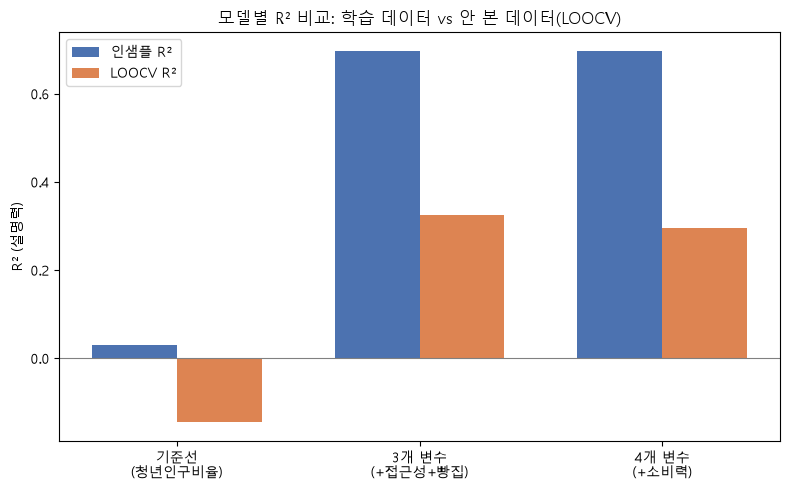

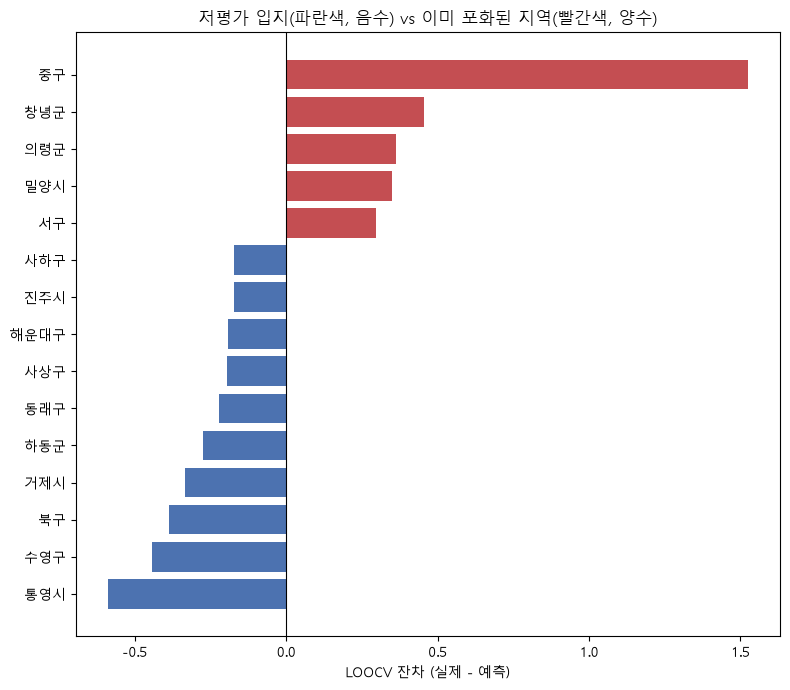

In [22]:
# 19. 결과 시각화하기
#
# 지금까지 표(숫자)로만 봤던 결과 두 가지를 그래프로 그립니다.
# ① 기준선 / 3개 변수 / 4개 변수(소비력 포함) 모델의 R² 비교 (인샘플 vs LOOCV)
#    -> "변수를 늘렸다고 항상 좋아지는 게 아니다"라는 이야기를 한눈에 보여줍니다.
# ② LOOCV 잔차 기준 저평가 입지 TOP 10 / 과잉공급 지역 TOP 5
#    -> 프로젝트의 최종 결론(어디가 기회지역인가)을 한눈에 보여줍니다.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score

# 0. 한글이 그래프에서 깨지지 않도록 폰트를 설정합니다. (윈도우는 보통 '맑은 고딕'이 있습니다)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스(-) 기호가 깨지는 것도 방지

# 1. 최종표 불러오기
파일경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv"
최종_df = pd.read_csv(파일경로, index_col=0, encoding="utf-8-sig")
y = 최종_df["카페_평균대비배수"]

# 2. LOOCV 함수 (15, 18번과 동일)
def LOOCV_검증(X, y):
    loo = LeaveOneOut()
    실제값_모음, 예측값_모음 = [], []
    for 학습_인덱스, 테스트_인덱스 in loo.split(X):
        X_학습, X_테스트 = X.iloc[학습_인덱스], X.iloc[테스트_인덱스]
        y_학습, y_테스트 = y.iloc[학습_인덱스], y.iloc[테스트_인덱스]
        모델 = LinearRegression()
        모델.fit(X_학습, y_학습)
        예측값 = 모델.predict(X_테스트)
        실제값_모음.append(y_테스트.values[0])
        예측값_모음.append(예측값[0])
    return r2_score(실제값_모음, 예측값_모음)

# 3. 세 모델을 다시 계산합니다.
모델_정의 = {
    "기준선\n(청년인구비율)": ["청년인구비율_19_39세"],
    "3개 변수\n(+접근성+빵집)": ["청년인구비율_19_39세", "유원지오락_평균대비배수", "빵도넛_평균대비배수"],
    "4개 변수\n(+소비력)": ["청년인구비율_19_39세", "유원지오락_평균대비배수", "빵도넛_평균대비배수", "소비력_평균대비배수"],
}

인샘플_R2_목록 = []
LOOCV_R2_목록 = []
for 이름, 변수목록 in 모델_정의.items():
    X = 최종_df[변수목록]
    모델 = LinearRegression().fit(X, y)
    인샘플_R2_목록.append(r2_score(y, 모델.predict(X)))
    LOOCV_R2_목록.append(LOOCV_검증(X, y))

# ---- 그래프 ① 모델별 R² 비교 (인샘플 vs LOOCV) ----
fig1, ax1 = plt.subplots(figsize=(8, 5))
x = np.arange(len(모델_정의))
너비 = 0.35

ax1.bar(x - 너비/2, 인샘플_R2_목록, 너비, label="인샘플 R²", color="#4C72B0")
ax1.bar(x + 너비/2, LOOCV_R2_목록, 너비, label="LOOCV R²", color="#DD8452")

ax1.set_xticks(x)
ax1.set_xticklabels(모델_정의.keys())
ax1.axhline(0, color="gray", linewidth=0.8)
ax1.set_ylabel("R² (설명력)")
ax1.set_title("모델별 R² 비교: 학습 데이터 vs 안 본 데이터(LOOCV)")
ax1.legend()
fig1.tight_layout()
fig1.savefig(r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\그래프1_모델비교.png", dpi=150)

# ---- 그래프 ② LOOCV 잔차 기준 저평가 입지 vs 과잉공급 지역 ----
잔차정렬 = 최종_df["LOOCV_잔차"].sort_values()
저평가_TOP10 = 잔차정렬.head(10)
과잉공급_TOP5 = 잔차정렬.tail(5)
합친표 = pd.concat([저평가_TOP10, 과잉공급_TOP5])

색상 = ["#4C72B0" if v < 0 else "#C44E52" for v in 합친표.values]

fig2, ax2 = plt.subplots(figsize=(8, 7))
ax2.barh(합친표.index, 합친표.values, color=색상)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_xlabel("LOOCV 잔차 (실제 - 예측)")
ax2.set_title("저평가 입지(파란색, 음수) vs 이미 포화된 지역(빨간색, 양수)")
fig2.tight_layout()
fig2.savefig(r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\그래프2_저평가입지.png", dpi=150)

print("그래프 2개 저장 완료: 그래프1_모델비교.png, 그래프2_저평가입지.png")
plt.show()

결과 / 알게 된 것 그래프1에서 기준선 모델은 LOOCV R²가 아예 음수(막대가 0 아래로 내려감)로 나와, 청년인구비율 하나만으로는 예측력이 없다는 게 시각적으로 바로 드러납니다. 3개 변수와 4개 변수 모델은 인샘플 R²는 거의 같지만(막대 높이 동일), LOOCV R²는 3개 변수 쪽이 더 높아서(주황 막대가 더 큼) 소비력을 뺀 3개 변수 모델이 최종 모델로 적절하다는 게 한눈에 확인됩니다. 그래프2에서는 통영시·수영구·북구·거제시·하동군 등이 파란색(저평가 입지)으로, 중구가 압도적으로 큰 빨간 막대(포화 지역)로 뚜렷하게 대비되어, 프로젝트의 핵심 결론이 그래프 하나로 요약됩니다.

20. 저평가 입지의 "절대 규모"를 확인하기

목적 통영시가 저평가 입지 1위로 나왔지만, "손님이 실제로 적을 것 같다"는 합리적인 의문이 제기됐습니다. 접근성 지표가 전부 "인구 1만명당"으로 정규화돼 있어서, 06번에서 겪었던 작은 분모 문제가 여기서도 반복됐을 가능성을 확인하기 위해 작성했습니다.

어떻게 했나 통영시·수영구·거제시·해운대구·중구·북구의 전체인구, 유원지오락 절대 개수, 인구 1만명당 값, 평균대비배수, 카페 수, LOOCV 잔차를 한 표에 모아 전체인구 기준으로 정렬했습니다. 34개 지역 전체 전체인구 중앙값과도 비교해서, 통영시의 인구 규모가 상대적으로 작은 편인지 확인했습니다.

In [23]:
# 20. 저평가 입지의 "절대 규모"를 확인하기
#
# 통영시가 저평가 입지 1위로 나왔는데, 이게 진짜 기회지역인지 아니면
# "인구가 적어서 비율이 튀어 보이는" 착시인지 확인해봅니다.
# 지금까지 쓴 접근성 지표는 전부 "인구 1만명당"으로 정규화된 값이라,
# 06번에서 겪었던 "작은 분모 문제"가 여기서도 똑같이 생길 수 있습니다.
# 그래서 정규화 전의 절대값(전체인구, 유원지오락 개수)을 나란히 비교합니다.

import pandas as pd

파일경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv"
최종_df = pd.read_csv(파일경로, index_col=0, encoding="utf-8-sig")

비교_지역 = ["통영시", "수영구", "거제시", "해운대구", "중구", "북구"]

비교표 = 최종_df.loc[비교_지역, [
    "전체인구",
    "유원지오락_개수",
    "인구1만명당_유원지오락",
    "유원지오락_평균대비배수",
    "카페",
    "LOOCV_잔차",
]]

# 전체인구 기준으로 정렬해서, 인구가 적은 지역일수록 비율이 튀는지 한눈에 보이게 합니다.
비교표 = 비교표.sort_values("전체인구")

print("[저평가 입지 후보들의 절대 규모 비교 (전체인구 적은 순)]")
print(비교표)

# 참고로 전체 34개 지역의 전체인구 중앙값과 비교해봅니다.
전체_중앙값 = 최종_df["전체인구"].median()
print(f"\n34개 지역 전체인구 중앙값: {전체_중앙값:,.0f}명")

[저평가 입지 후보들의 절대 규모 비교 (전체인구 적은 순)]
          전체인구  유원지오락_개수  인구1만명당_유원지오락  유원지오락_평균대비배수   카페  LOOCV_잔차
중구     38588.0        87         22.55          2.27  329  1.524856
통영시   118589.0       171         14.42          1.45  347 -0.589363
수영구   165275.0       149          9.02          0.91  493 -0.442427
거제시   240905.0       289         12.00          1.21  556 -0.333623
북구    259910.0       239          9.20          0.93  346 -0.386833
해운대구  362368.0       318          8.78          0.88  784 -0.190937

34개 지역 전체인구 중앙값: 134,525명


결과 / 알게 된 것 통영시 인구(118,589명)는 34개 지역 중앙값(134,525명)보다 조금 낮은 수준일 뿐, 중구(38,588명)처럼 극단적으로 작지는 않았습니다. 오히려 유원지오락 절대 개수(171개)는 통영시가 수영구(149개)보다 많았습니다 — 인구는 더 적은데 관광·여가 시설 절대 수는 더 많다는 뜻이라, 인구 1만명당 비율이 튄 게 "작은 분모 착시"는 아니라는 걸 확인했습니다. 카페 수도 통영시(347개)가 수영구(493개)보다 적어서, "관광 인프라는 있는데 카페는 상대적으로 적다"는 저평가 신호가 실제 절대값으로도 뒷받침됩니다. 다만 통영시의 전체 시장 규모(인구 118,589명) 자체는 해운대구(362,368명)·거제시(240,905명)보다 작은 것도 사실이라, "통계적 저평가율은 1위지만 절대 시장 규모는 중간"이라는 균형 잡힌 해석이 필요합니다. 규모까지 고려하면 거제시(인구 24만, 유원지오락 289개, 저평가 -0.334)가 저평가와 규모를 동시에 만족하는 안정적인 대안이 될 수 있습니다.

21. 매장 컨셉에 맞게 재순위화하기

목적 매장 컨셉이 "관광객이 들르는 대형 목적지형 카페"에서 "소규모 매장, 아침·점심·저녁마다 빵·스프를 사가는 식사 대용 컨셉"으로 구체화됐습니다. 이 컨셉은 관광객의 일회성 방문보다 평일마다 꾸준히 오는 수요(젊은 거주 인구)와 빵집 상권과의 시너지가 더 중요해서, 기존 저평가 입지 순위를 이 컨셉에 맞게 다시 계산하기 위해 작성했습니다.

어떻게 했나 유원지오락(관광·접근성) 축은 이번 컨셉과 관련이 낮다고 판단해 빼고, 청년인구비율(꾸준한 젊은 수요)과 빵도넛 인접성(빵집 상권 시너지) 두 변수만 사용했습니다. 두 변수는 단위가 달라서 z-score(표준화 점수, 평균 0·표준편차 1로 맞춘 값)로 바꾼 뒤 더해서 "신규컨셉_적합도점수"를 만들었습니다. 기존 저평가 입지 1~3위(통영시·거제시·수영구)가 이 새 점수에서는 어떻게 나오는지도 같이 확인했습니다.

In [24]:
# 21. 매장 컨셉에 맞게 재순위화하기
#
# 지금까지의 "저평가 입지" 순위는 유원지오락(관광·접근성)의 영향이 컸습니다.
# 그런데 컨셉을 다시 정하면서 이야기가 달라졌습니다:
#   - 소규모 매장, 앉아서 오래 머무는 카페가 아니라 아침/점심/저녁 시간대에
#     빵·스프를 사가는 "식사 대용" 컨셉
#   - 즉 관광객이 어쩌다 한 번 들르는 게 아니라, 평일 아침·점심·저녁마다
#     "꾸준히" 오는 사람이 있어야 하는 매장
#   - 분위기가 좋으면 젊은 사람들도 온다고 했으니, 청년 인구는 여전히 중요
#
# 그래서 이번엔 유원지오락(관광) 비중은 빼고, 청년인구비율(꾸준한 젊은 수요)과
# 빵도넛 인접성(같은 카테고리 상권 형성 여부)만으로 새로운 적합도 점수를 만듭니다.

import pandas as pd

파일경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv"
최종_df = pd.read_csv(파일경로, index_col=0, encoding="utf-8-sig")

# 1. 두 변수를 z-score(표준화 점수)로 바꿉니다.
#    z-score = (값 - 평균) / 표준편차 → 평균은 0, 단위가 서로 다른 두 변수를 더할 수 있게 맞춰줍니다.
def z_score(시리즈):
    return (시리즈 - 시리즈.mean()) / 시리즈.std()

최종_df["청년인구_z"] = z_score(최종_df["청년인구비율_19_39세"])
최종_df["빵도넛_z"] = z_score(최종_df["빵도넛_평균대비배수"])

# 2. 두 점수를 더해서 "신규 컨셉 적합도 점수"를 만듭니다. (둘 다 높을수록 좋은 입지)
최종_df["신규컨셉_적합도점수"] = 최종_df["청년인구_z"] + 최종_df["빵도넛_z"]

# 3. 참고용으로 기존 카페 경쟁밀도(낮을수록 아직 여지가 있는 곳)도 같이 보여줍니다.
결과표 = 최종_df[[
    "청년인구비율_19_39세",
    "빵도넛_평균대비배수",
    "신규컨셉_적합도점수",
    "카페_평균대비배수",
    "유원지오락_평균대비배수",
]].sort_values("신규컨셉_적합도점수", ascending=False)

print("[신규 컨셉(소규모 식사 대용 베이커리) 적합도 TOP 10]")
print(결과표.head(10))

print("\n[참고: 기존 '저평가 입지' 1~3위였던 지역의 신규컨셉 점수]")
print(결과표.loc[["통영시", "거제시", "수영구"]])

[신규 컨셉(소규모 식사 대용 베이커리) 적합도 TOP 10]
      청년인구비율_19_39세  빵도넛_평균대비배수  신규컨셉_적합도점수  카페_평균대비배수  유원지오락_평균대비배수
중구             27.7        2.70    5.277456       2.96          2.27
수영구            25.6        1.98    3.215078       1.04          0.91
부산진구           29.1        1.13    1.944845       0.91          0.85
진주시            25.5        1.25    1.519262       0.99          1.25
동구             23.5        1.26    1.152700       1.00          0.90
금정구            26.1        0.95    0.947213       0.90          1.11
강서구            25.8        0.94    0.865820       0.96          0.72
통영시            17.8        1.55    0.708494       1.02          1.45
남구             26.7        0.79    0.696653       0.61          0.73
김해시            25.0        0.87    0.549265       0.74          0.86

[참고: 기존 '저평가 입지' 1~3위였던 지역의 신규컨셉 점수]
     청년인구비율_19_39세  빵도넛_평균대비배수  신규컨셉_적합도점수  카페_평균대비배수  유원지오락_평균대비배수
통영시           17.8        1.55    0.708494       1.02          1.45
거제시           21.4        1.04  

결과 / 알게 된 것 1위는 중구(5.28점)였지만, 중구는 카페_평균대비배수가 2.96배로 34개 지역 중 압도적으로 이미 포화된 상권이라 신규 진입 후보로는 부적절합니다. 이 점수가 "기존 경쟁 강도"를 전혀 고려하지 않고 만들어졌다는 걸 보여주는 사례입니다. 그 다음으로 수영구(3.22점, 카페 경쟁도 1.04배로 평균 수준)와 부산진구(1.94점, 청년인구비율 29.1%로 전체 1위인데 카페 경쟁도는 0.91배로 오히려 평균 이하)가 눈에 띕니다. 반면 기존 저평가 입지 1~2위였던 통영시(0.71점, 8위)와 거제시(0.24점, 하위권)는 청년인구비율이 각각 17.8%, 21.4%로 낮아 순위가 크게 떨어졌습니다 — 관광 요인이 빠지자 "꾸준한 젊은 수요"가 부족한 지역이라는 게 드러난 것입니다.

22. 인구 "비율"이 아니라 "절대수"도 반영하고, 포화 상권의 실체를 확인하기

목적 두 가지 예리한 지적을 반영하기 위해 작성했습니다. 첫째, 청년인구비율은 비율(%)이라 인구가 적은 동네가 비율만 높게 나올 수 있어 전체인구(절대 규모)도 점수에 넣어야 한다는 지적입니다. 둘째, "카페가 많다 = 나쁨"이라는 가정이 항상 맞지 않으며, 상권 자체가 원래 크고 활발해서 포화돼도 매출이 잘 나올 수 있다는 지적입니다.

어떻게 했나 21번의 신규컨셉 적합도 점수에 전체인구 z-score를 추가해 v2 점수를 만들었습니다. 또한 전체상가수를 인구로 나눈 "상권규모_평균대비배수"를 새로 계산해서, 중구가 카페만 유독 몰린 곳인지 상권 자체가 원래 큰 곳인지 정황을 확인했습니다. 다만 이건 매장별 실제 매출 데이터가 아니라 간접적인 정황 증거일 뿐이라는 점을 코드 출력에도 명시했습니다.

In [25]:
# 22. 인구 "비율"이 아니라 "절대수"도 반영하고, 포화 상권의 실체를 확인하기
#
# 두 가지를 보완합니다.
# ① 지금까지 쓴 청년인구비율은 "비율(%)"이라, 인구 자체가 적은 동네가 비율만 높게
#    나올 수 있습니다. 전체인구도 점수에 반영해서 "절대적인 손님 수"까지 고려합니다.
# ② "카페가 많다 = 이미 포화 = 나쁨"이라는 가정이 항상 맞는 건 아닙니다.
#    전체상가수(상권 전체 규모)를 같이 보면, 그 지역이 카페만 유독 몰린 곳인지
#    아니면 상권 자체가 원래 크고 활발한 곳인지 짐작하는 데 도움이 됩니다.
#    (다만 이건 참고용 정황 증거일 뿐입니다 — 매장별 실제 매출 데이터가 없어서
#    "포화돼도 매출이 잘 나오는 곳"인지를 완전히 검증할 방법은 이번 데이터로는 없습니다.
#    이건 이 프로젝트가 가진 진짜 한계로 리포트에 남겨야 합니다.)

import pandas as pd

파일경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\구군별_카페_인구밀도_최종표.csv"
최종_df = pd.read_csv(파일경로, index_col=0, encoding="utf-8-sig")

def z_score(시리즈):
    return (시리즈 - 시리즈.mean()) / 시리즈.std()

# 1. 전체인구도 z-score로 추가해서 "절대 규모"를 반영합니다.
최종_df["전체인구_z"] = z_score(최종_df["전체인구"])
최종_df["청년인구_z"] = z_score(최종_df["청년인구비율_19_39세"])
최종_df["빵도넛_z"] = z_score(최종_df["빵도넛_평균대비배수"])

최종_df["신규컨셉_적합도점수_v2"] = (
    최종_df["청년인구_z"] + 최종_df["빵도넛_z"] + 최종_df["전체인구_z"]
)

결과표 = 최종_df[[
    "전체인구",
    "청년인구비율_19_39세",
    "빵도넛_평균대비배수",
    "신규컨셉_적합도점수_v2",
    "카페_평균대비배수",
    "전체상가수",
]].sort_values("신규컨셉_적합도점수_v2", ascending=False)

print("[전체인구까지 반영한 신규컨셉 적합도 TOP 10]")
print(결과표.head(10))

# 2. "포화 상권"이 실제로 상권 규모 자체가 큰 곳인지 확인합니다.
#    전체상가수를 인구로 나눠서, 중구가 카페만 유독 몰린 건지 상권 자체가 큰 건지 봅니다.
최종_df["인구1만명당_전체상가수"] = 최종_df["전체상가수"] / 최종_df["전체인구"] * 10000
전체_평균_상가밀도 = 최종_df["인구1만명당_전체상가수"].mean()
최종_df["상권규모_평균대비배수"] = 최종_df["인구1만명당_전체상가수"] / 전체_평균_상가밀도

print("\n[중구 vs 상위 후보지의 '상권 자체 규모' 비교]")
print(최종_df.loc[["중구", "수영구", "부산진구"], [
    "전체인구", "전체상가수", "인구1만명당_전체상가수", "상권규모_평균대비배수", "카페_평균대비배수",
]])

print("\n[참고] 이 지표는 정황 증거일 뿐입니다. 매장별 실제 매출 데이터가 없어서")
print("'포화됐지만 매출도 잘 나오는 곳'을 완전히 검증할 수는 없습니다 — 이번 프로젝트의 한계입니다.")

[전체인구까지 반영한 신규컨셉 적합도 TOP 10]
          전체인구  청년인구비율_19_39세  빵도넛_평균대비배수  신규컨셉_적합도점수_v2  카페_평균대비배수  전체상가수
창원시   992277.0           23.2        0.99       4.666872       0.83  51596
중구     38588.0           27.7        2.70       4.481072       2.96   7465
수영구   165275.0           25.6        1.98       3.081427       1.04  10214
부산진구  362555.0           29.1        1.13       2.843219       0.91  21012
김해시   552713.0           25.0        0.87       2.442406       0.74  26700
진주시   344145.0           25.5        1.25       2.321328       0.99  19577
양산시   363512.0           23.0        0.95       1.246828       0.82  16790
금정구   212610.0           26.1        0.95       1.061184       0.90  10318
남구    256859.0           26.7        0.79       1.042103       0.61   9532
해운대구  362368.0           21.0        1.01       0.989099       0.75  17753

[중구 vs 상위 후보지의 '상권 자체 규모' 비교]
          전체인구  전체상가수  인구1만명당_전체상가수  상권규모_평균대비배수  카페_평균대비배수
중구     38588.0   7465   1934.539235     3.343478       

In [1]:
# ============================================================
# STEP 00. 프로젝트 폴더를 공식 가이드 구조에 맞게 정리하기
# ------------------------------------------------------------
# 목표: 지금까지 한 폴더에 평평하게 쌓여있던 파일들을
#       data/raw, data/processed, notebooks, reports/figures, references
#       구조로 정리합니다. (출처: drivendataorg/cookiecutter-data-science)
#
# 주의: 이 스크립트를 실행하면 01~23번 스크립트 안에 적힌 절대경로가
#       새 폴더 위치와 안 맞게 됩니다. 이미 실행 결과는 각 .md 파일에
#       정리돼 있으니 당장 문제는 없지만, 나중에 특정 스크립트를 다시
#       실행해야 한다면 그 스크립트의 경로만 새로 고쳐야 합니다.
# ============================================================

import os
import re
import shutil
import glob

프로젝트_루트 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정"

# ------------------------------------------------------------
# 1) 폴더 구조 만들기
# ------------------------------------------------------------
폴더_목록 = [
    "data/raw/소상공인시장진흥공단_상권정보",
    "data/interim",
    "data/processed",
    "notebooks",
    "models",
    "reports/figures",
    "references",
]
for 폴더 in 폴더_목록:
    os.makedirs(os.path.join(프로젝트_루트, 폴더), exist_ok=True)
print("[1/6] 폴더 구조 생성 완료!")


def 안전하게_이동(원본_상대경로, 대상_상대경로):
    """파일이 실제로 있을 때만 이동합니다. 없으면 조용히 건너뜁니다."""
    원본 = os.path.join(프로젝트_루트, 원본_상대경로)
    대상 = os.path.join(프로젝트_루트, 대상_상대경로)
    if os.path.exists(원본):
        shutil.move(원본, 대상)
        print(f"  이동: {원본_상대경로}  ->  {대상_상대경로}")
    else:
        print(f"  (건너뜀 - 없음) {원본_상대경로}")


# ------------------------------------------------------------
# 2) 원본 데이터 -> data/raw
# ------------------------------------------------------------
안전하게_이동(
    "소상공인시장진흥공단_상권정보/소상공인시장진흥공단_상가(상권)정보_부산_202606.csv",
    "data/raw/소상공인시장진흥공단_상권정보/소상공인시장진흥공단_상가(상권)정보_부산_202606.csv",
)
안전하게_이동(
    "소상공인시장진흥공단_상권정보/소상공인시장진흥공단_상가(상권)정보_경남_202606.csv",
    "data/raw/소상공인시장진흥공단_상권정보/소상공인시장진흥공단_상가(상권)정보_경남_202606.csv",
)
안전하게_이동(
    "인구총조사_청년인구비율_시도_시_군_구__20260827173438.csv",
    "data/raw/인구총조사_청년인구비율_시도_시_군_구__20260827173438.csv",
)
안전하게_이동(
    "101_DT_1K52F08_20260828142803.csv",
    "data/raw/101_DT_1K52F08_20260828142803.csv",
)
print("[2/6] 원본 데이터 이동 완료!")

# ------------------------------------------------------------
# 3) 가공된 결과물 -> data/processed (중간 산출물은 data/interim)
# ------------------------------------------------------------
안전하게_이동("구군별_카페_인구밀도_최종표.csv", "data/processed/구군별_카페_인구밀도_최종표.csv")
안전하게_이동("Top5_카페_위치.csv", "data/processed/Top5_카페_위치.csv")
안전하게_이동("구군별_카페_비중표.csv", "data/interim/구군별_카페_비중표.csv")
print("[3/6] 가공 데이터 이동 완료!")

# ------------------------------------------------------------
# 4) 번호가 붙은 스크립트(.py)와 설명(.md) -> notebooks
#    "01_...", "23_..." 처럼 숫자로 시작하는 파일만 골라서 이동합니다.
# ------------------------------------------------------------
숫자로_시작하는_파일들 = glob.glob(os.path.join(프로젝트_루트, "[0-9]*_*.py")) + \
                    glob.glob(os.path.join(프로젝트_루트, "[0-9]*_*.md"))

for 파일경로 in 숫자로_시작하는_파일들:
    파일명 = os.path.basename(파일경로)
    if re.match(r"^\d+_.+\.(py|md)$", 파일명):
        안전하게_이동(파일명, f"notebooks/{파일명}")

# ipynb 노트북도 있으면 같이 이동
안전하게_이동("1.0-eda.ipynb", "notebooks/1.0-eda.ipynb")
print("[4/6] 스크립트/노트북 이동 완료!")

# ------------------------------------------------------------
# 5) 그래프 PNG -> reports/figures, 대시보드 -> reports
# ------------------------------------------------------------
for 그래프_파일 in ["그래프1_모델비교.png", "그래프2_저평가입지.png",
                 "그래프_상관관계히트맵.png", "그래프_대상변수분포.png"]:
    안전하게_이동(그래프_파일, f"reports/figures/{그래프_파일}")

안전하게_이동("카페입지분석_대시보드.html", "reports/카페입지분석_대시보드.html")
print("[5/6] 그래프/리포트 이동 완료!")

# ------------------------------------------------------------
# 6) requirements.txt, README.md, references/data_dictionary.md 새로 작성
# ------------------------------------------------------------
requirements_내용 = """pandas
numpy
scikit-learn
matplotlib
folium
"""
with open(os.path.join(프로젝트_루트, "requirements.txt"), "w", encoding="utf-8") as f:
    f.write(requirements_내용)

readme_내용 = """# 부산·경남 카페 입지 분석 (1차 프로젝트)

## 문제 정의
유통(베이커리) 업종에서 부산·경남 지역에 소규모 카페(아침·점심·저녁 빵/스프 판매 컨셉)를
새로 열 때, 34개 구·군 중 어디가 적합한지 데이터로 분석합니다.

## 데이터 출처
- 소상공인시장진흥공단 상가(상권)정보 (부산·경남)
- 통계청 인구총조사 (청년인구비율, 전체인구)
- KOSIS 시도별 산업별 매출액 (숙박 및 음식점업)
- 소상공인시장진흥공단 소상공인365 (행정동 단위 매출·유동인구, 선택적 보강자료)

## 폴더 구조
- `data/raw/` : 원본 데이터. 수정하지 않습니다.
- `data/interim/` : 전처리 중간 산출물
- `data/processed/` : 분석·모델링에 바로 쓰는 데이터
- `notebooks/` : 번호가 붙은 분석 스크립트(01~23번)와 설명(.md)
- `reports/` : 대시보드, 최종 산출물
- `reports/figures/` : 리포트에 쓰인 그래프 이미지
- `references/` : 데이터 사전(컬럼 설명)

## 실행 방법
1. `pip install -r requirements.txt`
2. `notebooks/` 안의 스크립트를 번호 순서대로 실행 (01번부터)
   - 주의: 이 폴더 정리 스크립트(00번) 실행 이후에는 각 스크립트 안의
     절대경로를 새 폴더 구조에 맞게 수정해야 재실행이 가능합니다.

## 진행 순서 요약
1. 데이터 이해 (01~02번)
2. 데이터 준비/병합 (03~12번)
3. 회귀모델링 + LOOCV 검증 (13~19번)
4. 인사이트 검증 (20~22번)
5. Top5 지역 지도 시각화 (23번~)
"""
with open(os.path.join(프로젝트_루트, "README.md"), "w", encoding="utf-8") as f:
    f.write(readme_내용)

data_dictionary_내용 = """# 데이터 사전 (구군별_카페_인구밀도_최종표.csv)

| 컬럼명 | 의미 |
|---|---|
| 빵/도넛 | 해당 구·군의 빵/도넛 업종 매장 수 |
| 카페 | 해당 구·군의 카페 업종 매장 수 |
| 전체상가수 | 해당 구·군의 전체 상가(모든 업종) 수 |
| 카페_비중(%) | 전체상가수 대비 카페 비중 |
| 빵도넛_비중(%) | 전체상가수 대비 빵/도넛 비중 |
| 시도명 | 부산광역시 / 경상남도 |
| 청년인구비율_19_39세 | 19~39세 인구가 전체 인구에서 차지하는 비율(%) |
| 전체인구 | 해당 구·군의 전체 인구 수 |
| 인구1만명당_카페수 | 인구 1만 명당 카페 개수 |
| 카페1개당_인구수 | 카페 1개당 담당하는 인구 수 |
| 평균대비_밀집배수 | (초기 버전) 평균 대비 카페 밀집 배수 |
| 유원지오락_개수 | 유원지/오락 업종 매장 수 (관광·접근성 지표) |
| 인구1만명당_유원지오락 | 인구 1만 명당 유원지/오락 매장 수 |
| 인구1만명당_빵도넛 | 인구 1만 명당 빵/도넛 매장 수 |
| 카페_평균대비배수 | 34개 지역 평균 대비 카페 밀도 배수 (회귀모델의 예측 대상) |
| 유원지오락_평균대비배수 | 34개 지역 평균 대비 유원지/오락 밀도 배수 |
| 빵도넛_평균대비배수 | 34개 지역 평균 대비 빵/도넛 밀도 배수 |
| LOOCV_예측값 | LOOCV로 검증한 회귀모델이 예측한 카페_평균대비배수 |
| LOOCV_잔차 | 실제값 - 예측값. 음수일수록 저평가(기회) 입지 |
| 숙박음식점업_매출액(백만원) | KOSIS 시도 단위 숙박및음식점업 매출액 (부산/경남 2개 값만 존재) |
| 소비력_평균대비배수 | 위 매출액의 평균 대비 배수 (최종모델에서는 LOOCV 성능 저하로 제외됨) |
"""
with open(os.path.join(프로젝트_루트, "references", "data_dictionary.md"), "w", encoding="utf-8") as f:
    f.write(data_dictionary_내용)

print("[6/6] requirements.txt, README.md, references/data_dictionary.md 작성 완료!")
print("\n프로젝트 폴더 정리가 모두 끝났습니다!")

[1/6] 폴더 구조 생성 완료!
  이동: 소상공인시장진흥공단_상권정보/소상공인시장진흥공단_상가(상권)정보_부산_202606.csv  ->  data/raw/소상공인시장진흥공단_상권정보/소상공인시장진흥공단_상가(상권)정보_부산_202606.csv
  이동: 소상공인시장진흥공단_상권정보/소상공인시장진흥공단_상가(상권)정보_경남_202606.csv  ->  data/raw/소상공인시장진흥공단_상권정보/소상공인시장진흥공단_상가(상권)정보_경남_202606.csv
  이동: 인구총조사_청년인구비율_시도_시_군_구__20260827173438.csv  ->  data/raw/인구총조사_청년인구비율_시도_시_군_구__20260827173438.csv
  (건너뜀 - 없음) 101_DT_1K52F08_20260828142803.csv
[2/6] 원본 데이터 이동 완료!
  이동: 구군별_카페_인구밀도_최종표.csv  ->  data/processed/구군별_카페_인구밀도_최종표.csv
  (건너뜀 - 없음) Top5_카페_위치.csv
  이동: 구군별_카페_비중표.csv  ->  data/interim/구군별_카페_비중표.csv
[3/6] 가공 데이터 이동 완료!
  이동: 00_프로젝트_폴더_정리하기.py  ->  notebooks/00_프로젝트_폴더_정리하기.py
  이동: 01_상가정보_불러오기.py  ->  notebooks/01_상가정보_불러오기.py
  이동: 02_카페_업종명_확인하기.py  ->  notebooks/02_카페_업종명_확인하기.py
  이동: 03_카페_구군별_개수세기.py  ->  notebooks/03_카페_구군별_개수세기.py
  이동: 04_부산_경남_합치기.py  ->  notebooks/04_부산_경남_합치기.py
  이동: 05_카페_빵집_구군별_비교표.py  ->  notebooks/05_카페_빵집_구군별_비교표.py
  이동: 06_카페_비중_계산하기.py  ->  notebooks/06_카페_비중_계산하기.py
  이동: 0